# Which London Wards Have Higher or Lower Violent Crime Than a Machine Learning Model Would Expect?

## Preparation
- [Github Link](https://github.com/nxwelena07/CASA0006-Assessment.git)

- Number of words: 1480

- Runtime: 3 minutes (*Memory 16 GB, CPU i386 8 core*)

- Coding environment: Anaconda

- License: this notebook is made available under the [Creative Commons Attribution license](https://creativecommons.org/licenses/by/4.0/).

## Table of contents

1. [Introduction](#Introduction)

1. [Research questions](#Research-questions)

1. [Data](#Data)

1. [Methodology](#Methodology)

1. [Results and discussion](#Results-and-discussion)

1. [Conclusion](#Conclusion)

1. [References](#References)

## 1. Introduction

[[ go back to the top ]](#Table-of-contents)

As a city characterized by high concentration of population density, economic activity, and transient populations, London’s distribution of violent crime is not merely a collection of isolated incidents but an urban social phenomenon with distinct spatial structure. The law of crime concentration posits that urban violent crime tends to be highly concentrated at relatively fine spatial scales (Weisburd 2015). Violent crime levels are closely linked to neighborhood social structure, such as social cohesion and capacity for informal social control (Sampson et al. 1997). Meanwhile, crime risk exhibits certain degree of spatial and temporal continuity. Applying machine learning to historical crime pattern data (Bowers et al. 2004) and multi-source urban data (Bogomolov et al. 2014) holds significant importance to predict potential future high-risk areas and implement urban safety risk interventions. However, many studies remain focused on identifying high-crime places or improving the predictive accuracy of models, lacking an analysis of the contributions of different feature groups and the translation of model results into spatial diagnostic tools.

## 2. Research questions

[[ go back to the top ]](#Table-of-contents)

This study aims to investigate whether machine learning models could utilize data regarding recent crime history, seasonal patterns, and socio-demographic characteristics to predict violent crime at the ward level. Furthermore, it seeks to examine which wards exhibit actual crime rates that systematically exceed or fall below these predictions.

## 3. Data

[[ go back to the top ]](#Table-of-contents)

### 3.0 Preparation

In [1]:
import os
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
import matplotlib.pyplot as plt
%matplotlib inline
import shap

In [2]:
# Data Folder
DATA_DIR = "data"
# File Path
CRIME_HIST = os.path.join(DATA_DIR, "MPS Ward Level Crime (Historical).csv")
CRIME_RECENT = os.path.join(DATA_DIR, "MPS Ward Level Crime (most recent 24 months).csv")
ACC_FILE = os.path.join(DATA_DIR, "accommodation type.xlsx")
EA_FILE = os.path.join(DATA_DIR, "Economic Activity.xlsx")
AGE_FILE = os.path.join(DATA_DIR, "Five year age bands.xlsx")
HEALTH_FILE = os.path.join(DATA_DIR, "General health.xlsx")

In [3]:
# Define Data Cleaning: convert to string, remove spaces, convert to uppercase
def clean_code(series):
    return series.astype(str).str.strip().str.upper()

### 3.1 Crime Dataset

The primary data are derived from historical and recent  [MPS Ward-Level London Crime Records](https://data.london.gov.uk/dataset/mps-recorded-crime-geographic-breakdown-exy3m/).

In [4]:
# read data
hist = pd.read_csv(CRIME_HIST)
recent = pd.read_csv(CRIME_RECENT)

# clean data
for df in [hist, recent]: 
    df["WardCode"] = clean_code(df["WardCode"])
    df["WardName"] = df["WardName"].astype(str).str.strip()

print("Historical shape:", hist.shape)
print("Recent shape:", recent.shape)

hist.head()

Historical shape: (21130, 173)
Recent shape: (18669, 30)


,WardName,WardCode,MajorText,MinorText,LookUp_BoroughName,201004,201005,201006,201007,201008,...,202306,202307,202308,202309,202310,202311,202312,202401,202402,202403
0,Heathrow Villages,E05013570,ARSON AND CRIMINAL DAMAGE,ARSON,Aviation Security (SO18),0,0,0,0,0,...,2,2,0,0,0,0,1,3,0,2
1,Heathrow Villages,E05013570,ARSON AND CRIMINAL DAMAGE,CRIMINAL DAMAGE,Aviation Security (SO18),0,0,0,0,0,...,18,16,23,24,19,17,36,25,28,21
2,Heathrow Villages,E05013570,BURGLARY,BURGLARY BUSINESS AND COMMUNITY,Aviation Security (SO18),0,0,0,0,0,...,2,2,4,6,3,1,4,2,9,6
3,Heathrow Villages,E05013570,BURGLARY,RES BURGLARY OF A HOME,Aviation Security (SO18),0,0,0,0,0,...,3,6,11,12,1,7,8,11,7,3
4,Heathrow Villages,E05013570,BURGLARY,RES BURGLARY OF UNCONNECTED BUILDING,Aviation Security (SO18),0,0,0,0,0,...,2,2,3,2,0,3,3,1,0,1


In [5]:
# identify month columns
month_cols_hist = [c for c in hist.columns if str(c).isdigit()]
month_cols_recent = [c for c in recent.columns if str(c).isdigit()]

# remove 202403 from recent data, only use 202403 from historical data
month_cols_recent = [c for c in month_cols_recent if c != "202403"]

print("Historical months:", month_cols_hist[:3], "...", month_cols_hist[-3:], "| total =", len(month_cols_hist))
print("Recent months:", month_cols_recent[:3], "...", month_cols_recent[-3:], "| total =", len(month_cols_recent))

Historical months: ['201004', '201005', '201006'] ... ['202401', '202402', '202403'] | total = 168
Recent months: ['202404', '202405', '202406'] ... ['202601', '202602', '202603'] | total = 24


In [6]:
# aggregate from minor category to major category
hist_major = (hist[["WardCode", "WardName", "MajorText"] + month_cols_hist].groupby(["WardCode", "WardName", "MajorText"], as_index=False).sum(numeric_only=True))
recent_major = (recent[["WardCode", "WardName", "MajorText"] + month_cols_recent].groupby(["WardCode", "WardName", "MajorText"], as_index=False).sum(numeric_only=True))

print("Historical major-category shape:", hist_major.shape)
print("Recent major-category shape:", recent_major.shape)

hist_major.head()

Historical major-category shape: (8155, 171)
Recent major-category shape: (7594, 27)


,WardCode,WardName,MajorText,201004,201005,201006,201007,201008,201009,201010,...,202306,202307,202308,202309,202310,202311,202312,202401,202402,202403
0,E05009317,Bethnal Green,ARSON AND CRIMINAL DAMAGE,20,22,22,20,15,15,21,...,11,10,17,13,10,5,12,12,23,13
1,E05009317,Bethnal Green,BURGLARY,6,17,12,14,15,20,17,...,14,14,19,9,13,18,9,8,13,8
2,E05009317,Bethnal Green,DRUG OFFENCES,16,15,13,16,11,13,20,...,12,24,19,14,7,10,13,7,15,16
3,E05009317,Bethnal Green,FRAUD AND FORGERY,0,7,3,4,4,6,3,...,0,0,0,0,0,0,0,0,0,0
4,E05009317,Bethnal Green,MISCELLANEOUS CRIMES AGAINST SOCIETY,1,3,0,4,2,2,2,...,6,4,3,3,0,0,0,4,4,3


In [7]:
# build tidy long table 
hist_long = hist_major.melt(
    id_vars=["WardCode", "WardName", "MajorText"],
    var_name="month", value_name="count")
recent_long = recent_major.melt(
    id_vars=["WardCode", "WardName", "MajorText"],
    var_name="month", value_name="count")
crime_long = pd.concat([hist_long, recent_long], ignore_index=True).rename(columns={"MajorText": "crime_type"})
crime_long["month"] = pd.to_datetime(crime_long["month"], format="%Y%m")

print(crime_long.shape)
crime_long.head()

(1552296, 5)


,WardCode,WardName,crime_type,month,count
0,E05009317,Bethnal Green,ARSON AND CRIMINAL DAMAGE,2010-04-01,20
1,E05009317,Bethnal Green,BURGLARY,2010-04-01,6
2,E05009317,Bethnal Green,DRUG OFFENCES,2010-04-01,16
3,E05009317,Bethnal Green,FRAUD AND FORGERY,2010-04-01,0
4,E05009317,Bethnal Green,MISCELLANEOUS CRIMES AGAINST SOCIETY,2010-04-01,1


### 3.2 Static Ward-Level Features

The following four datasets from [Estimates for London wards and LSOAs (2021)](https://data.london.gov.uk/census/2021-ward-and-lsoa-estimates/) are used to represent static ward-level features: 
- Population by age: Five year age bands
- Economic Activity: Adults' Economic Activity status
- Accommodation type: Type of house or flat
- Health: General health

In [8]:
### Accommodation Type

# read & clean data
acc = pd.read_excel(ACC_FILE, sheet_name="2021")
acc.columns = [c.strip() for c in acc.columns]
acc = acc.rename(columns={
    "ward code": "WardCode",
    "ward name": "WardName",
    "local authority name": "Borough"
})
acc = acc[acc["WardCode"] != "E09000001"].copy()
acc["WardCode"] = clean_code(acc["WardCode"])
acc["Borough"] = acc["Borough"].astype(str).str.strip()

# Construct proportional variables
acc["pct_purpose_built_flat"] = acc["Purpose built flat"] / acc["All households"]
acc["pct_detached"] = acc["Detached"] / acc["All households"]

acc_features = acc[[
    "WardCode",
    "WardName",
    "Borough",
    "pct_purpose_built_flat",
    "pct_detached"
]]

print(acc_features.shape)
acc_features.head()

(679, 5)


,WardCode,WardName,Borough,pct_purpose_built_flat,pct_detached
1,E05014053,Abbey,Barking and Dagenham,0.678129,0.025447
2,E05014054,Alibon,Barking and Dagenham,0.130422,0.059527
3,E05014055,Barking Riverside,Barking and Dagenham,0.528943,0.042823
4,E05014056,Beam,Barking and Dagenham,0.113938,0.071534
5,E05014057,Becontree,Barking and Dagenham,0.090140,0.056948


In [9]:
### Economic Activity

# read & clean data
ea = pd.read_excel(EA_FILE, sheet_name="2021")
ea.columns = [c.strip() for c in ea.columns]
ea = ea.rename(columns={"ward code": "WardCode"})
ea = ea[ea["WardCode"] != "E09000001"].copy()
ea["WardCode"] = clean_code(ea["WardCode"])

# Construct proportional variables
ea["unemployment_rate"] = ea["Unemployed"] / ea["Economically active Total"]
ea["inactivity_rate"] = ea["Economically inactive Total"] / ea["All usual residents aged 16+"]

ea_features = ea[[
    "WardCode",
    "unemployment_rate",
    "inactivity_rate"
]]

print(ea_features.shape)
ea_features.head()

(679, 3)


,WardCode,unemployment_rate,inactivity_rate
1,E05014053,0.069927,0.307249
2,E05014054,0.069653,0.347412
3,E05014055,0.072636,0.280023
4,E05014056,0.075878,0.358388
5,E05014057,0.082011,0.373162


In [10]:
### Population by age

# read & clean data
age = pd.read_excel(AGE_FILE, sheet_name="2021")
age.columns = [c.strip() for c in age.columns]
age = age.rename(columns={
    "ward code": "WardCode",
    "All usual residents": "Total_Pop"})
age = age[age["WardCode"] != "E09000001"].copy()
age["WardCode"] = clean_code(age["WardCode"])

# Construct proportional variables
age["pct_age_15_24"] = (age["Aged 15 to 19 years"] + age["Aged 20 to 24 years"]) / age["Total_Pop"]

age_features = age[[
    "WardCode",
    "pct_age_15_24",
    "Total_Pop"
]]

print(age_features.shape)
age_features.head()

(679, 3)


,WardCode,pct_age_15_24,Total_Pop
1,E05014053,0.096008,3958
2,E05014054,0.134555,9877
3,E05014055,0.114777,10063
4,E05014056,0.137403,8355
5,E05014057,0.133810,9790


In [11]:
### Health

# read & clean data
health = pd.read_excel(HEALTH_FILE, sheet_name="2021")
health.columns = [c.strip() for c in health.columns]
health = health.rename(columns={"ward code": "WardCode"})
health = health[health["WardCode"] != "E09000001"].copy()
health["WardCode"] = clean_code(health["WardCode"])

# Construct proportional variables
health["pct_bad_very_bad"] = (health["Bad health"] + health["Very bad health"]) / health["All Usual residents"]

health_features = health[[
    "WardCode",
    "pct_bad_very_bad"
]].copy()

print(health_features.shape)
health_features.head()

(679, 2)


,WardCode,pct_bad_very_bad
1,E05014053,0.034561
2,E05014054,0.051407
3,E05014055,0.033201
4,E05014056,0.042350
5,E05014057,0.058126


### 3.3 Merge Crime and Static Ward Features

In [12]:
# Merge all static ward features
static_features = (acc_features
                   .merge(ea_features, on="WardCode", how="inner")
                   .merge(age_features, on="WardCode", how="inner")
                   .merge(health_features, on="WardCode", how="inner"))

print(static_features.shape)
print("Unique WardCode:", static_features["WardCode"].nunique())
static_features.head()

(679, 10)
Unique WardCode: 679


,WardCode,WardName,Borough,pct_purpose_built_flat,pct_detached,unemployment_rate,inactivity_rate,pct_age_15_24,Total_Pop,pct_bad_very_bad
0,E05014053,Abbey,Barking and Dagenham,0.678129,0.025447,0.069927,0.307249,0.096008,3958,0.034561
1,E05014054,Alibon,Barking and Dagenham,0.130422,0.059527,0.069653,0.347412,0.134555,9877,0.051407
2,E05014055,Barking Riverside,Barking and Dagenham,0.528943,0.042823,0.072636,0.280023,0.114777,10063,0.033201
3,E05014056,Beam,Barking and Dagenham,0.113938,0.071534,0.075878,0.358388,0.137403,8355,0.042350
4,E05014057,Becontree,Barking and Dagenham,0.090140,0.056948,0.082011,0.373162,0.133810,9790,0.058126


In [13]:
# Pivot crime types to ward-month panel
crime_panel = (crime_long.pivot_table(
    index=["WardCode", "WardName", "month"], 
    columns="crime_type", values="count", 
    aggfunc="sum", fill_value=0
).reset_index())
crime_panel.columns.name = None

# use Borough from static_features instead of crime 
# because Heathrow Villages appeared in special mapping in historical data
crime_panel = crime_panel.merge(static_features[["WardCode", "Borough"]], on="WardCode", how="left")
crime_panel = crime_panel.sort_values(["WardCode", "month"]).reset_index(drop=True)

print(crime_panel.shape)
print("Unique WardCode:", crime_panel["WardCode"].nunique())
crime_panel.head()

(130368, 17)
Unique WardCode: 679


,WardCode,WardName,month,ARSON AND CRIMINAL DAMAGE,BURGLARY,DRUG OFFENCES,FRAUD AND FORGERY,MISCELLANEOUS CRIMES AGAINST SOCIETY,NFIB FRAUD,POSSESSION OF WEAPONS,PUBLIC ORDER OFFENCES,ROBBERY,SEXUAL OFFENCES,THEFT,VEHICLE OFFENCES,VIOLENCE AGAINST THE PERSON,Borough
0,E05009317,Bethnal Green,2010-04-01,20,6,16,0,1,0,1,5,8,3,49,19,32,Tower Hamlets
1,E05009317,Bethnal Green,2010-05-01,22,17,15,7,3,0,1,9,7,0,49,20,53,Tower Hamlets
2,E05009317,Bethnal Green,2010-06-01,22,12,13,3,0,0,0,2,5,3,33,16,48,Tower Hamlets
3,E05009317,Bethnal Green,2010-07-01,20,14,16,4,4,0,0,6,6,5,40,26,39,Tower Hamlets
4,E05009317,Bethnal Green,2010-08-01,15,15,11,4,2,0,0,7,6,2,39,13,39,Tower Hamlets


In [14]:
# Merge static ward features into panel
crime_panel = crime_panel.merge(static_features.drop(columns=["WardName", "Borough"]), on="WardCode", how="inner")

print(crime_panel.shape)
crime_panel.head()

(130368, 24)


,WardCode,WardName,month,ARSON AND CRIMINAL DAMAGE,BURGLARY,DRUG OFFENCES,FRAUD AND FORGERY,MISCELLANEOUS CRIMES AGAINST SOCIETY,NFIB FRAUD,POSSESSION OF WEAPONS,...,VEHICLE OFFENCES,VIOLENCE AGAINST THE PERSON,Borough,pct_purpose_built_flat,pct_detached,unemployment_rate,inactivity_rate,pct_age_15_24,Total_Pop,pct_bad_very_bad
0,E05009317,Bethnal Green,2010-04-01,20,6,16,0,1,0,1,...,19,32,Tower Hamlets,0.79682,0.008426,0.071184,0.370463,0.195284,21205,0.052312
1,E05009317,Bethnal Green,2010-05-01,22,17,15,7,3,0,1,...,20,53,Tower Hamlets,0.79682,0.008426,0.071184,0.370463,0.195284,21205,0.052312
2,E05009317,Bethnal Green,2010-06-01,22,12,13,3,0,0,0,...,16,48,Tower Hamlets,0.79682,0.008426,0.071184,0.370463,0.195284,21205,0.052312
3,E05009317,Bethnal Green,2010-07-01,20,14,16,4,4,0,0,...,26,39,Tower Hamlets,0.79682,0.008426,0.071184,0.370463,0.195284,21205,0.052312
4,E05009317,Bethnal Green,2010-08-01,15,15,11,4,2,0,0,...,13,39,Tower Hamlets,0.79682,0.008426,0.071184,0.370463,0.195284,21205,0.052312


### 3.4 Target Definition and Feature Engineering

In [15]:
# define target variable
crime_panel["violent_count"] = crime_panel["VIOLENCE AGAINST THE PERSON"]
crime_panel["target_log_count"] = np.log1p(crime_panel["violent_count"])

crime_panel[["violent_count","target_log_count"]].head()

,violent_count,target_log_count
0,32,3.496508
1,53,3.988984
2,48,3.891820
3,39,3.688879
4,39,3.688879


In [16]:
# Create lag, rolling, calendar features
crime_panel = crime_panel.sort_values(["WardCode", "month"])
g = crime_panel.groupby("WardCode")

# violent crime history
crime_panel["violent_lag1"] = g["violent_count"].shift(1)
crime_panel["violent_lag2"] = g["violent_count"].shift(2)
crime_panel["violent_roll3"] = g["violent_count"].transform(lambda s: s.shift(1).rolling(3).mean())
crime_panel["violent_roll6"] = g["violent_count"].transform(lambda s: s.shift(1).rolling(6).mean())
crime_panel["violent_roll12"] = g["violent_count"].transform(lambda s: s.shift(1).rolling(12).mean())
crime_panel["violent_std3"] = g["violent_count"].transform(lambda s: s.shift(1).rolling(3).std())

# lagged values of other major crime categories
other_crimes = ["ROBBERY", "BURGLARY", "THEFT", "DRUG OFFENCES", "PUBLIC ORDER OFFENCES", "VEHICLE OFFENCES"]
for col in other_crimes:
    new_col = col.lower().replace(" ", "_") + "_lag1"
    crime_panel[new_col] = g[col].shift(1)

# calendar features
crime_panel["year"] = crime_panel["month"].dt.year
crime_panel["month_num"] = crime_panel["month"].dt.month
crime_panel["quarter"] = crime_panel["month"].dt.quarter
crime_panel["is_summer"] = crime_panel["month_num"].isin([6, 7, 8]).astype(int)
crime_panel["is_december"] = (crime_panel["month_num"] == 12).astype(int)

crime_panel.head()

,WardCode,WardName,month,ARSON AND CRIMINAL DAMAGE,BURGLARY,DRUG OFFENCES,FRAUD AND FORGERY,MISCELLANEOUS CRIMES AGAINST SOCIETY,NFIB FRAUD,POSSESSION OF WEAPONS,...,burglary_lag1,theft_lag1,drug_offences_lag1,public_order_offences_lag1,vehicle_offences_lag1,year,month_num,quarter,is_summer,is_december
0,E05009317,Bethnal Green,2010-04-01,20,6,16,0,1,0,1,...,NaN,NaN,NaN,NaN,NaN,2010,4,2,0,0
1,E05009317,Bethnal Green,2010-05-01,22,17,15,7,3,0,1,...,6.0,49.0,16.0,5.0,19.0,2010,5,2,0,0
2,E05009317,Bethnal Green,2010-06-01,22,12,13,3,0,0,0,...,17.0,49.0,15.0,9.0,20.0,2010,6,2,1,0
3,E05009317,Bethnal Green,2010-07-01,20,14,16,4,4,0,0,...,12.0,33.0,13.0,2.0,16.0,2010,7,3,1,0
4,E05009317,Bethnal Green,2010-08-01,15,15,11,4,2,0,0,...,14.0,40.0,16.0,6.0,26.0,2010,8,3,1,0


In [17]:
# Drop NA rows after feature engineering
model_df = crime_panel.dropna().copy()

print("crime_panel shape:", crime_panel.shape)
print("model_df shape:", model_df.shape)
print("Unique WardCode in model_df:", model_df["WardCode"].nunique())
print("Time range:", model_df["month"].min(), "to", model_df["month"].max())

crime_panel shape: (130368, 43)
model_df shape: (122220, 43)
Unique WardCode in model_df: 679
Time range: 2011-04-01 00:00:00 to 2026-03-01 00:00:00


In [18]:
# Final feature list
feature_cols = [
    # violent crime history
    "violent_lag1","violent_lag2","violent_roll3","violent_roll6","violent_roll12","violent_std3",
    # other crime lag features
    "robbery_lag1","burglary_lag1","theft_lag1","drug_offences_lag1","public_order_offences_lag1","vehicle_offences_lag1",
    # static ward features
    "pct_purpose_built_flat","pct_detached","unemployment_rate","inactivity_rate","pct_age_15_24","pct_bad_very_bad",
    # calendar features
    "year","month_num","quarter","is_summer","is_december"
]

X = model_df[feature_cols]
y = model_df["target_log_count"]

### 3.5 Variables Table

| Variable | Type | Description | Notes |
|---|---|---|---|
| WardCode | Identifier | Unique ward code used to merge ward-level crime records with static ward-level feature tables. | Not used as a model predictor |
| WardName | Identifier | Name of the London ward. Used for interpretation and residual ranking. | Not used as a model predictor |
| Borough | Categorical | London borough containing the ward. Used for reporting and aggregation. | Not used directly as a model predictor |
| month | Datetime | Monthly timestamp for each ward-month observation. | Used to construct calendar variables and time-based train/validation/test split |
| violent_count | Numeric | Monthly count of `VIOLENCE AGAINST THE PERSON` in each ward. | Raw target before transformation |
| target_log_count | Numeric | Log-transformed violent crime count, calculated as `log1p(violent_count)`. | Main dependent variable for regression models |
| violent_lag1 | Numeric | Violent crime count in the previous month for the same ward. | Dynamic crime-history predictor |
| violent_lag2 | Numeric | Violent crime count two months before the current observation for the same ward. | Dynamic crime-history predictor |
| violent_roll3 | Numeric | Mean violent crime count over the previous three months for the same ward. | Dynamic trend predictor |
| violent_roll6 | Numeric | Mean violent crime count over the previous six months for the same ward. | Dynamic trend predictor |
| violent_roll12 | Numeric | Mean violent crime count over the previous twelve months for the same ward. | Dynamic trend predictor |
| violent_std3 | Numeric | Standard deviation of violent crime count over the previous three months for the same ward. | Measures short-term volatility |
| robbery_lag1 | Numeric | Robbery count in the previous month for the same ward. | Other crime-history predictor |
| burglary_lag1 | Numeric | Burglary count in the previous month for the same ward. | Other crime-history predictor |
| theft_lag1 | Numeric | Theft count in the previous month for the same ward. | Other crime-history predictor |
| drug_offences_lag1 | Numeric | Drug offences count in the previous month for the same ward. | Other crime-history predictor |
| public_order_offences_lag1 | Numeric | Public order offences count in the previous month for the same ward. | Other crime-history predictor|
| vehicle_offences_lag1 | Numeric | Vehicle offences count in the previous month for the same ward. | Other crime-history predictor |
| pct_purpose_built_flat | Numeric | Share of households living in purpose-built flats. | Static ward-level housing structure feature |
| pct_detached | Numeric | Share of households living in detached accommodation. | Static ward-level housing structure feature |
| unemployment_rate | Numeric | Share of unemployed residents among the economically active population. | Static ward-level labour-market feature |
| inactivity_rate | Numeric | Share of economically inactive residents among residents aged 16 and over. | Static ward-level labour-market feature |
| pct_age_15_24 | Numeric | Share of residents aged 15–24. | Static ward-level demographic feature |
| pct_bad_very_bad | Numeric | Share of residents reporting bad or very bad general health. | Static ward-level vulnerability feature |
| year | Numeric | Year extracted from the monthly timestamp. | Calendar feature used to capture long-term temporal drift|
| month_num | Numeric | Month number from 1 to 12. | Calendar feature used to capture monthly seasonality |
| quarter | Numeric | Calendar quarter from 1 to 4. | Calendar feature used to capture seasonal structure |
| is_summer | Binary | Indicator equal to 1 for June, July, and August, and 0 otherwise. | Calendar feature for summer months |
| is_december | Binary | Indicator equal to 1 for December, and 0 otherwise. | Calendar feature for December-specific effects |

## 4. Methodology

[[ go back to the top ]](#Table-of-contents)

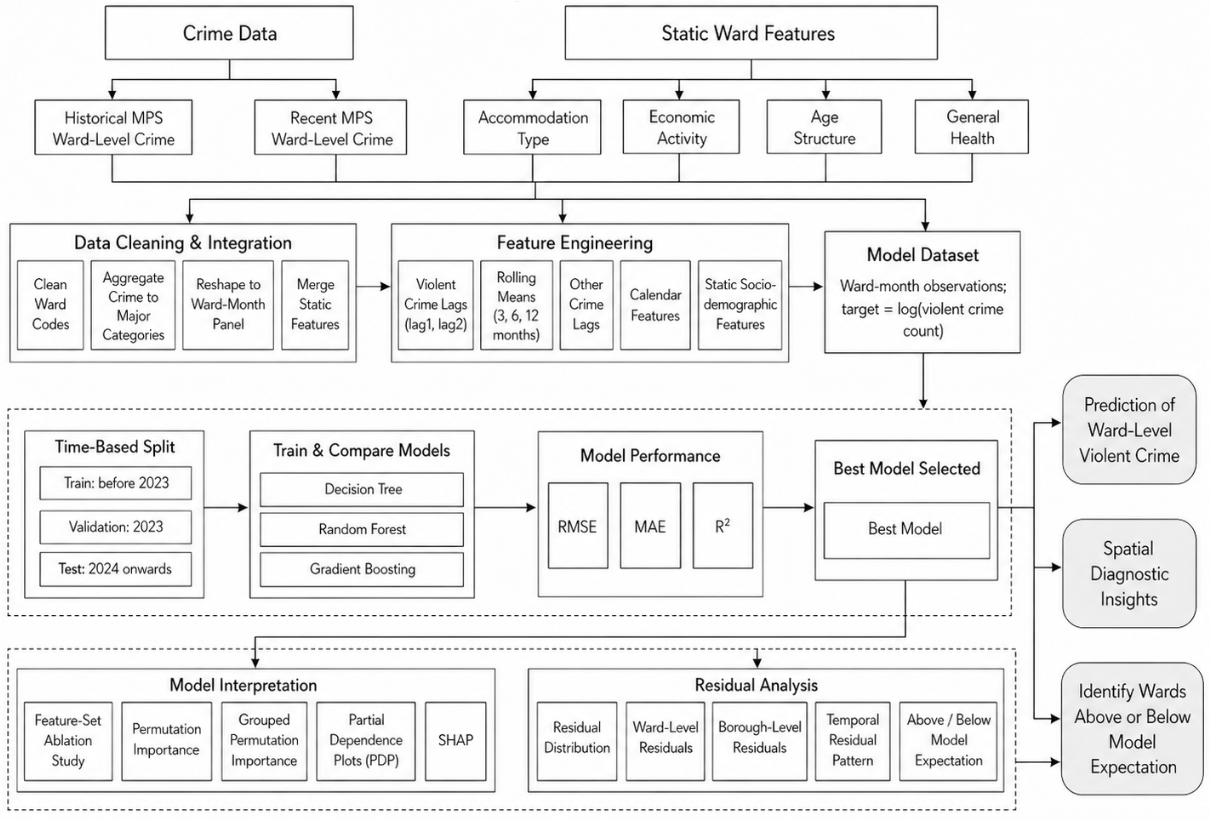
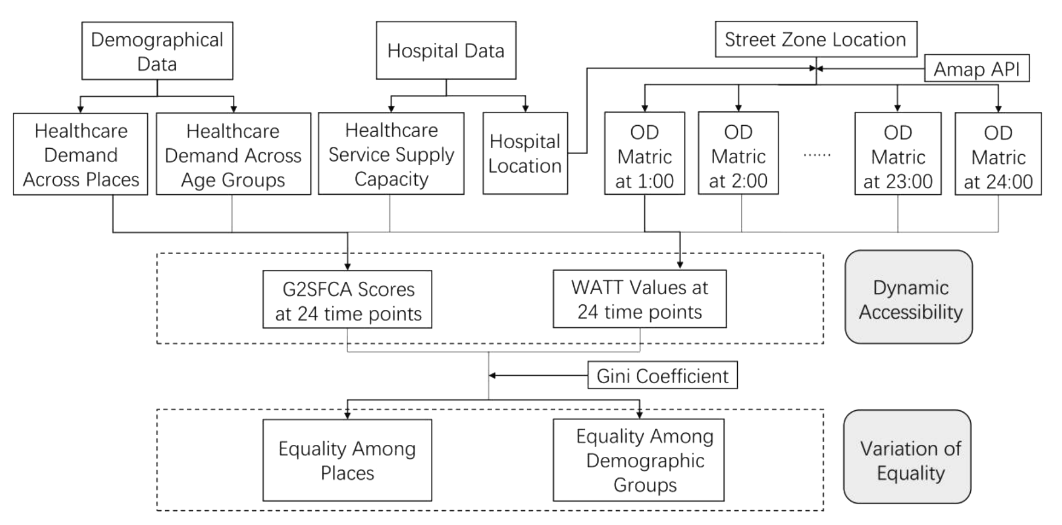

### 4.0 Analytical Framework

This study utilizes three tree-based supervised regression models to forecast violent crime at the ward level.

A Decision Tree was employed as baseline model. By iteratively partitioning the feature space, it assigns samples to distinct terminal leaves and provides a predictive value within each leaf. The maximum depth of the tree was limited to prevent the model from overfitting training data. Furthermore, each leaf was required to contain a minimum number of samples, thereby mitigating the predictive instability that can result from overly fine-grained partitioning. However, a single Decision Tree is prone to being overly sensitive to local noise present in the training data.

As bagging-based ensemble model, Random Forest mitigates the instability inherent in individual trees by averaging the predictions of multiple decision trees. The total model successfully lowers variance, allowing for more reliable forecasts of violent crime at the ward level, since each tree is usually trained on unique bootstrap samples and discrete subsets of characteristics.

Moreover, ward-level violent crime prediction is characterized by complex nonlinear relationships and variable interactions. Gradient Boosting is a boosting-based ensemble model. It uses a sequential learning approach where each new tree tries to fix the prediction errors of previous models. It can learn these complicated patterns, and also has good predictive performance on structured tabular data by fitting the residuals sequentially.

The primary metric for the model evaluation is validation RMSE as it is more sensitive to larger errors. Besides, MAE and R2 are also used to measure the performance of the model, which represent the means absolute error and the percentage of the variance of the target variable that the model can explain.

Finally, the study applies residual analysis to identify wards with actual violent crime that is systematically higher or lower than model expectations.

### 4.1 Time-Based Train, Validation, and Test Split

Instead of a random split, a time-based split is employed to prevent future data leakage. Training set uses observations before 2023. Validation set uses data from 2023. Testing set uses data from 2024 and beyond.

In [19]:
# time-based split
train_df = model_df[model_df["month"] < "2023-01-01"].copy()
valid_df = model_df[(model_df["month"] >= "2023-01-01") & (model_df["month"] < "2024-01-01")].copy()
test_df  = model_df[model_df["month"] >= "2024-01-01"].copy()
print("Train period:", train_df["month"].min(), "to", train_df["month"].max())
print("Valid period:", valid_df["month"].min(), "to", valid_df["month"].max())
print("Test period :", test_df["month"].min(), "to", test_df["month"].max())

Train period: 2011-04-01 00:00:00 to 2022-12-01 00:00:00
Valid period: 2023-01-01 00:00:00 to 2023-12-01 00:00:00
Test period : 2024-01-01 00:00:00 to 2026-03-01 00:00:00


### 4.2 Model Inputs

In [20]:
# prepare modelling matrices
X_train = train_df[feature_cols]
y_train = train_df["target_log_count"]
X_valid = valid_df[feature_cols]
y_valid = valid_df["target_log_count"]
X_test = test_df[feature_cols]
y_test = test_df["target_log_count"]

print("Train:", X_train.shape, y_train.shape)
print("Valid:", X_valid.shape, y_valid.shape)
print("Test :", X_test.shape, y_test.shape)

Train: (95739, 23) (95739,)
Valid: (8148, 23) (8148,)
Test : (18333, 23) (18333,)


## 5. Results and discussion

[[ go back to the top ]](#Table-of-contents)

### 5.1 Descriptive Patterns

#### 5.1.0 Preparation

In [21]:
# prepare descriptive datasets
desc_df = crime_panel.copy()
desc_df["violent_count"] = desc_df["VIOLENCE AGAINST THE PERSON"]
desc_df["year"] = desc_df["month"].dt.year
desc_df["month_num"] = desc_df["month"].dt.month
desc_df["month_name"] = desc_df["month"].dt.strftime("%b")

#### 5.1.1 Monthly Violent Crime Trend

There was a long-term upward trend in violent crime in London at the ward level, from around 11,000 to 19,000.  It is also characterized by short-term fluctuations during 2020 to 2022 and phase-specific changes, such as relatively low levels between 2011 and 2013.

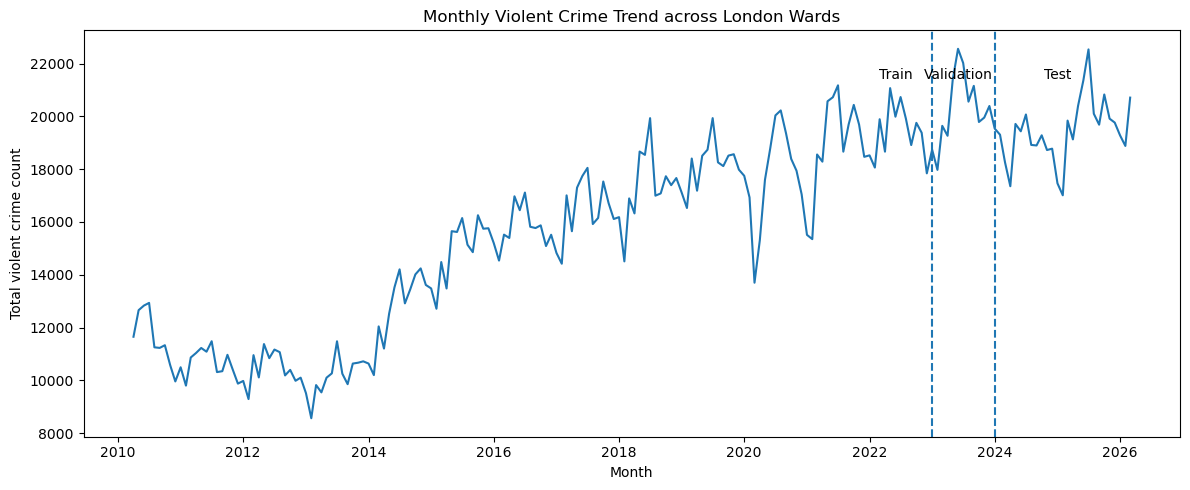

In [22]:
# monthly violent crime trend
monthly_trend = (desc_df.groupby("month", as_index=False)["violent_count"]
                 .sum().sort_values("month"))

plt.figure(figsize=(12, 5))
plt.plot(monthly_trend["month"], monthly_trend["violent_count"])
plt.title("Monthly Violent Crime Trend across London Wards")
plt.xlabel("Month")
plt.ylabel("Total violent crime count")

# train, validation, test split markers
plt.axvline(pd.Timestamp("2023-01-01"), linestyle="--")
plt.axvline(pd.Timestamp("2024-01-01"), linestyle="--")
plt.text(pd.Timestamp("2022-06-01"), monthly_trend["violent_count"].max()*0.95, "Train", ha="center")
plt.text(pd.Timestamp("2023-06-01"), monthly_trend["violent_count"].max()*0.95, "Validation", ha="center")
plt.text(pd.Timestamp("2025-01-01"), monthly_trend["violent_count"].max()*0.95, "Test", ha="center")

plt.tight_layout()
plt.show()

#### 5.1.2 Violent Crime by Calendar Month

Violent crime is subject to some calendar seasonality. July has the highest average with 25.68, followed by June and May, indicating that the summer months could be in line with higher levels of violent criminal activity. On the other hand, February has the lowest average with a value of 21.55. January, April and December also have relatively low averages. This suggests that winter months or shorter months may correspond to lower average crime counts.

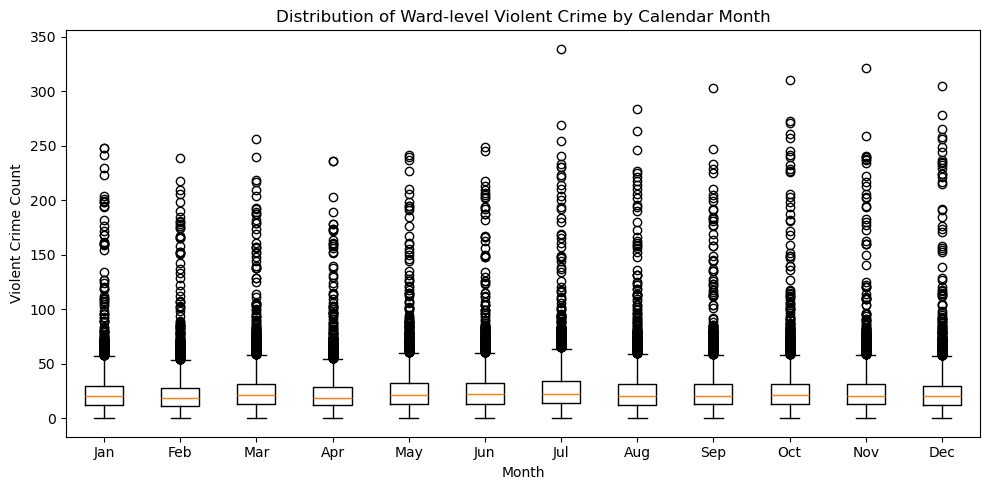

In [23]:
# seasonality by calendar month
month_order = list(range(1, 13))
month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
monthly_box = [desc_df.loc[desc_df["month_num"] == m, "violent_count"].values for m in month_order]
plt.figure(figsize=(10, 5))
plt.boxplot(monthly_box, tick_labels=month_labels)
plt.title("Distribution of Ward-level Violent Crime by Calendar Month")
plt.xlabel("Month")
plt.ylabel("Violent Crime Count")
plt.tight_layout()
plt.show()

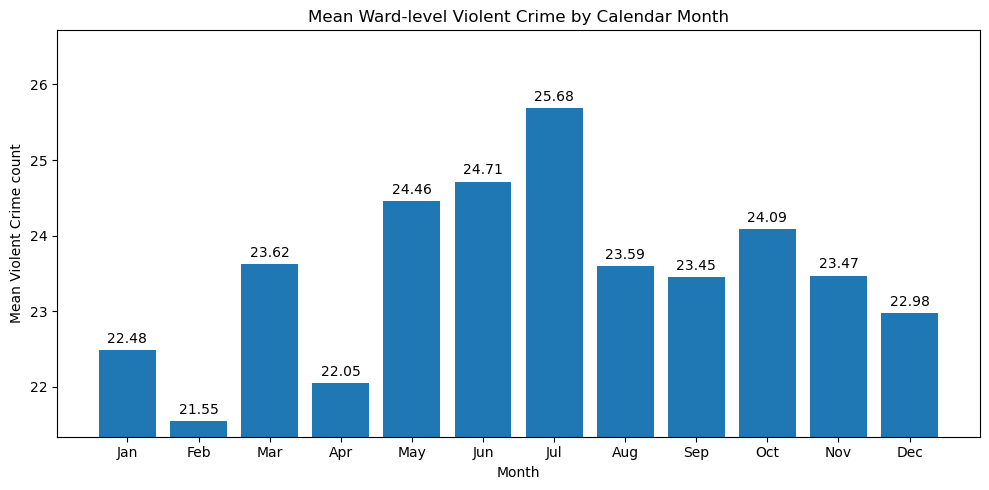

In [24]:
# mean violent crime by calendar month
mean_by_month = (desc_df.groupby("month_num", as_index=False)["violent_count"]
                 .mean().sort_values("month_num"))
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(mean_by_month["month_num"], mean_by_month["violent_count"])
ax.set_xticks(mean_by_month["month_num"])
ax.set_xticklabels(month_labels)
ax.set_title("Mean Ward-level Violent Crime by Calendar Month")
ax.set_xlabel("Month")
ax.set_ylabel("Mean Violent Crime count")

y = mean_by_month["violent_count"].values
y_min, y_max = y.min(), y.max()
pad = max((y_max - y_min) * 0.25, 0.3)
ax.set_ylim(y_min - pad * 0.2, y_max + pad)
ax.bar_label(bars, fmt="%.2f", padding=3)

plt.tight_layout()
plt.show()

#### 5.1.3 Top and Bottom 10 Wards by Mean Violent Crime

Violent crime in London is very concentrated at the ward level. The average values for St James’s (181.9) and West End (164.2) are significantly higher than the other wards. In contrast, the highest mean value among the bottom 10 wards was in King George’s & Sunray at only 6.0.

In [25]:
# Top 10 wards by mean violent crime
ward_mean_violent = (desc_df.groupby(["WardCode", "WardName", "Borough"], as_index=False)["violent_count"]
                     .mean().rename(columns={"violent_count": "mean_violent_count"}))
top10_wards = ward_mean_violent.sort_values("mean_violent_count", ascending=False).head(10)
top10_wards

,WardCode,WardName,Borough,mean_violent_count
459,E05013806,St James's,Westminster,181.911458
461,E05013808,West End,Westminster,164.203125
127,E05011468,Fairfield,Croydon,95.604167
154,E05013501,Harlesden & Kensal Green,Brent,59.322917
163,E05013510,Stonebridge,Brent,56.953125
223,E05013570,Heathrow Villages,Hillingdon,56.739583
30,E05009377,Hoxton East & Shoreditch,Hackney,56.432292
539,E05013938,Kingston Town,Kingston upon Thames,56.385417
383,E05013730,Rushey Green,Lewisham,55.505208
233,E05013580,Uxbridge,Hillingdon,55.276042


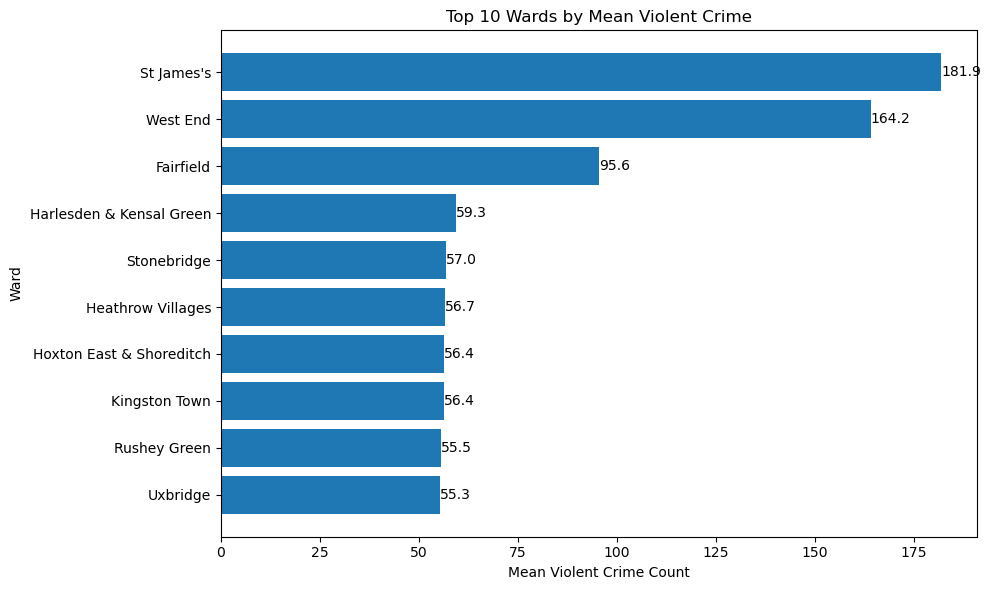

In [26]:
# Plot Top 10 wards
plot_df = top10_wards.sort_values("mean_violent_count", ascending=True)
plt.figure(figsize=(10, 6))
bars = plt.barh(plot_df["WardName"], plot_df["mean_violent_count"])
plt.xlabel("Mean Violent Crime Count")
plt.ylabel("Ward")
plt.title("Top 10 Wards by Mean Violent Crime")
for bar, v in zip(bars, plot_df["mean_violent_count"]):
    plt.text(bar.get_width(), bar.get_y() + bar.get_height()/2, f"{v:.1f}", va="center")
plt.tight_layout()
plt.show()

In [27]:
# Bottom 10 wards by mean violent crime
bottom10_wards = ward_mean_violent.sort_values("mean_violent_count", ascending=True).head(10)
bottom10_wards

,WardCode,WardName,Borough,mean_violent_count
530,E05013929,Berrylands,Kingston upon Thames,3.541667
426,E05013773,Worcester Park South,Sutton,3.958333
547,E05013946,Tudor,Kingston upon Thames,4.338542
134,E05011475,Park Hill & Whitgift,Croydon,4.390625
540,E05013939,Motspur Park & Old Malden East,Kingston upon Thames,4.973958
529,E05013928,Alexandra,Kingston upon Thames,5.156250
334,E05013681,Grange Park,Enfield,5.229167
597,E05014016,Northcote,Wandsworth,5.682292
577,E05013996,Darwin,Bromley,5.734375
537,E05013936,King George's & Sunray,Kingston upon Thames,5.979167


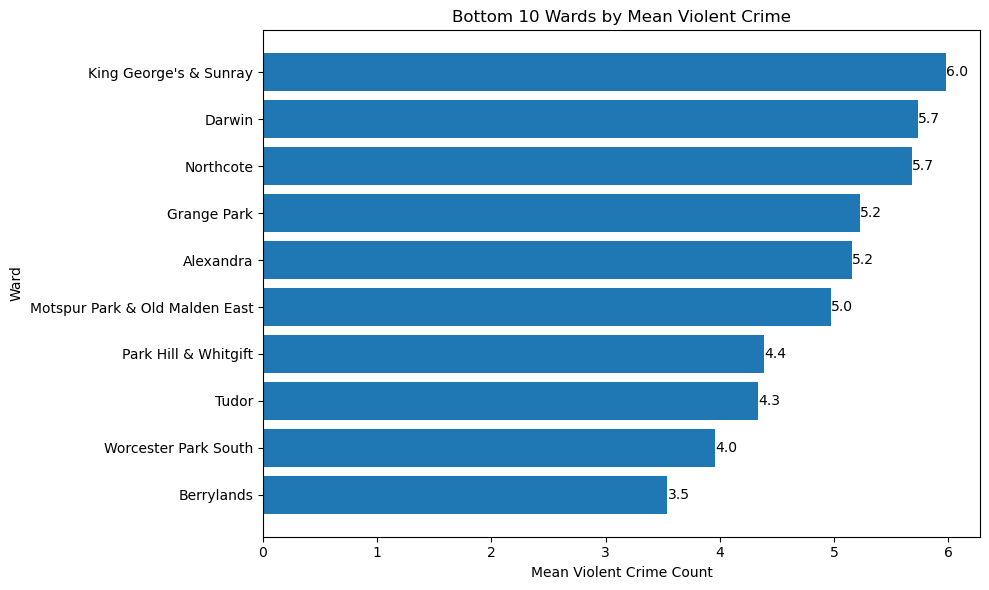

In [28]:
# Plot bottom 10 wards
plot_df = bottom10_wards.sort_values("mean_violent_count", ascending=True)
plt.figure(figsize=(10, 6))
bars = plt.barh(plot_df["WardName"], plot_df["mean_violent_count"])
plt.xlabel("Mean Violent Crime Count")
plt.ylabel("Ward")
plt.title("Bottom 10 Wards by Mean Violent Crime")
for bar, v in zip(bars, plot_df["mean_violent_count"]):
    plt.text(bar.get_width(), bar.get_y() + bar.get_height()/2, f"{v:.1f}", va="center")
plt.tight_layout()
plt.show()

#### 5.1.4 Mean Violent Crime by Borough

The spatial heterogeneity is also large in the aggregation at the borough level. Central London and certain inner or high-activity boroughs, particularly Westminster, exhibit higher average violent crime count, while some outer London boroughs have relatively lower averages.

In [29]:
# Mean violent crime by borough
borough_mean_violent = (desc_df.groupby("Borough", as_index=False)["violent_count"]
                        .mean().rename(columns={"violent_count": "mean_violent_count"}).sort_values("mean_violent_count", ascending=False))
borough_mean_violent.head(10)

,Borough,mean_violent_count
31,Westminster,40.734664
21,Lewisham,32.278783
28,Tower Hamlets,32.164583
3,Brent,29.442708
23,Newham,28.474392
17,Islington,28.437500
10,Hackney,27.381696
7,Ealing,27.357856
26,Southwark,27.215580
20,Lambeth,26.972500


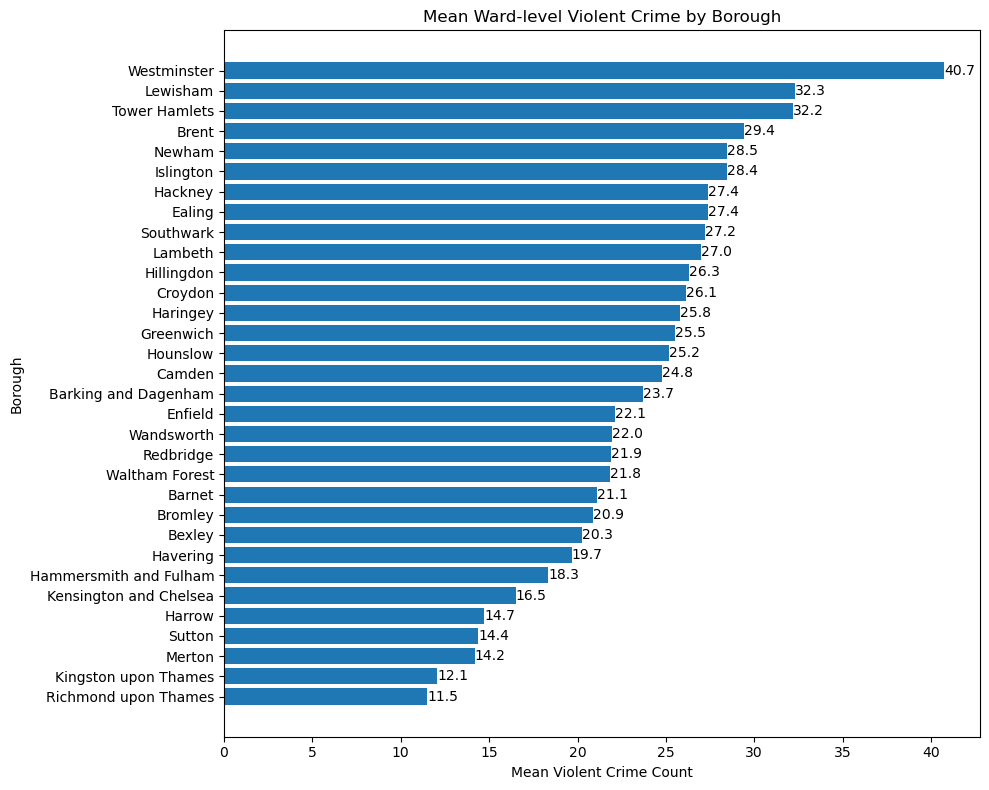

In [30]:
# Plot mean violent crime by borough
plot_df = borough_mean_violent.sort_values("mean_violent_count", ascending=True)
plt.figure(figsize=(10, 8))
bars = plt.barh(plot_df["Borough"], plot_df["mean_violent_count"])
plt.xlabel("Mean Violent Crime Count")
plt.ylabel("Borough")
plt.title("Mean Ward-level Violent Crime by Borough")
for bar, v in zip(bars, plot_df["mean_violent_count"]):
    plt.text(bar.get_width(), bar.get_y() + bar.get_height()/2, f"{v:.1f}", va="center")
plt.tight_layout()
plt.show()

### 5.2 Model Performance

#### 5.2.1 Train & Compare Models

Gradient Boosting is better than Random Forest and Decision Trees for error control and interpretability. It obtained the minimum RMSE and MAE values and the maximum R2 score on validation and test sets. It exhibits good predictive performance (around 79%) on urban crime data with remarkable spatial heterogeneity and temporal fluctuation. It has therefore been chosen as the best model to use in further analyses. Nevertheless, the performance gap among the three models is relatively narrow. It appears that the primary predictive signals within the data may have already been effectively captured by features such as crime history, rolling averages, and calendar-related variables. 

In [31]:
# define evaluation function
def evaluate_regression(model, X, y, split_name="validation"):
    pred = model.predict(X)
    mse = mean_squared_error(y, pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y, pred)
    r2 = r2_score(y, pred)
    
    return pd.DataFrame({"split": [split_name], "RMSE": [rmse], "MAE": [mae], "R2": [r2]})

In [32]:
# define models
models = {
    "DecisionTree": DecisionTreeRegressor(max_depth=8, min_samples_leaf=20, random_state=42),
    "RandomForest": RandomForestRegressor(n_estimators=150, max_depth=None, min_samples_leaf=5, n_jobs=-1, random_state=42),
    "GradientBoosting": GradientBoostingRegressor(n_estimators=150, learning_rate=0.05, max_depth=3, subsample=0.8, random_state=42)
         }

In [33]:
# train models & compare performance
results = []
fitted_models = {}

for model_name, model in models.items():
    model.fit(X_train, y_train)
    fitted_models[model_name] = model
    
    # calculate RMSE, MAE, R2
    valid_metrics = evaluate_regression(model, X_valid, y_valid, split_name="validation")
    valid_metrics.insert(0, "model", model_name)
    test_metrics = evaluate_regression(model, X_test, y_test, split_name="test")
    test_metrics.insert(0, "model", model_name)
    
    results.append(valid_metrics)
    results.append(test_metrics)
results_df = pd.concat(results, ignore_index=True)

# separate validation & test results
valid_results = results_df[results_df["split"] == "validation"].sort_values("RMSE").reset_index(drop=True)
test_results = results_df[results_df["split"] == "test"].sort_values("RMSE").reset_index(drop=True)
print("Validation results:")
display(valid_results)
print("Test results:")
display(test_results)

Validation results:


,model,split,RMSE,MAE,R2
0,GradientBoosting,validation,0.258167,0.200266,0.805401
1,RandomForest,validation,0.260392,0.202876,0.802033
2,DecisionTree,validation,0.262559,0.203222,0.798724


Test results:


,model,split,RMSE,MAE,R2
0,GradientBoosting,test,0.267935,0.204497,0.793925
1,RandomForest,test,0.269870,0.206156,0.790938
2,DecisionTree,test,0.272498,0.207685,0.786846


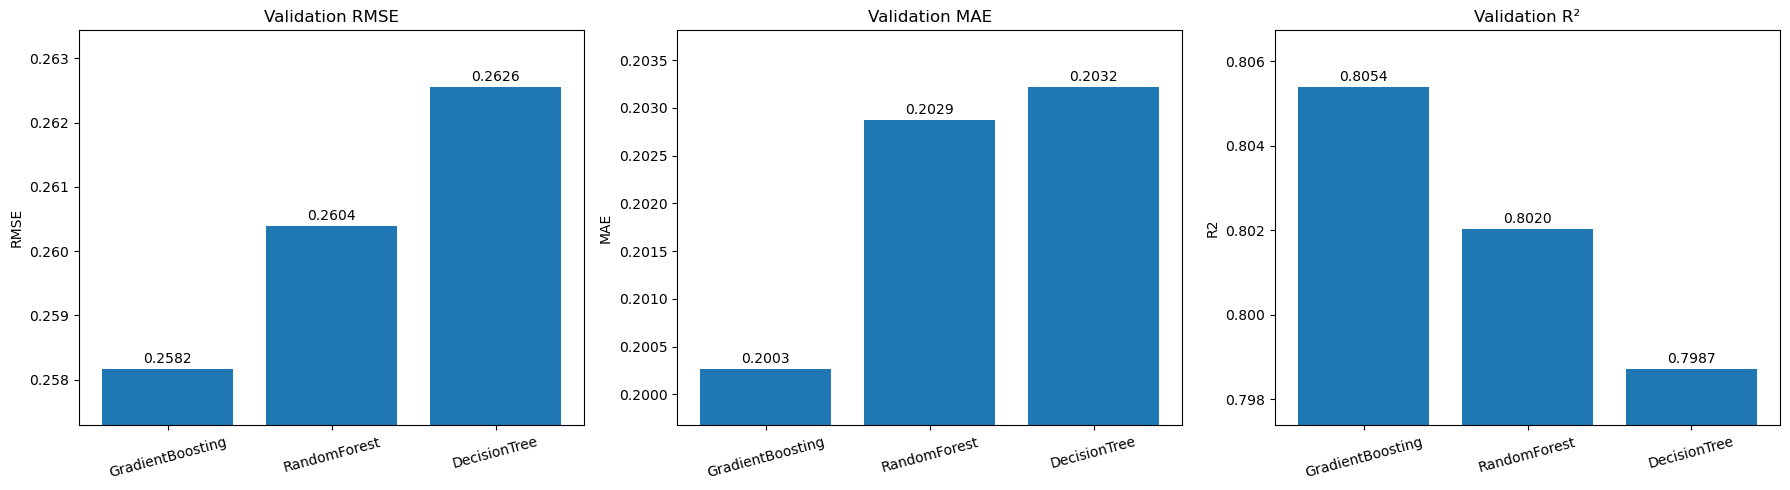

In [34]:
# plot model comparison
plot_df = valid_results
metrics = [("RMSE", "Validation RMSE"),
           ("MAE", "Validation MAE"),
           ("R2", "Validation R²")]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (metric, title) in zip(axes, metrics):
    # sorting
    if metric in ["RMSE", "MAE"]: 
        tmp = plot_df.sort_values(metric, ascending=True).reset_index(drop=True)
    else: 
        tmp = plot_df.sort_values(metric, ascending=False).reset_index(drop=True)

    x = np.arange(len(tmp))
    y = tmp[metric].values

    # chart
    bars = ax.bar(x, y)
    ax.set_xticks(x)
    ax.set_xticklabels(tmp["model"], rotation=15)
    ax.set_title(title)
    ax.set_ylabel(metric)
    # adjust y-axis
    y_min, y_max = y.min(), y.max()
    pad = (y_max - y_min) * 0.2 if y_max > y_min else 0.05
    ax.set_ylim(y_min - pad, y_max + pad)
    # numerical annotation
    for bar, v in zip(bars, y): 
        ax.text(bar.get_x() + bar.get_width() / 2, v + pad * 0.05, f"{v:.4f}", ha="center", va="bottom")

plt.tight_layout()
plt.show()

In [35]:
# select best model by validation RMSE
best_model_name = valid_results.iloc[0]["model"]
best_model = fitted_models[best_model_name]
print("Best model selected from validation set:", best_model_name)

Best model selected from validation set: GradientBoosting


#### 5.2.2 Plot Actual vs Prediction

The Gradient Boosting model is capable of capturing the primary patterns of variation in ward-level violent crime. The point cloud is generally distributed along 45-degree line, particularly within the range where the actual log violent crime count falls between 2.5 and 4.2. However, it also exhibits a certain pattern of regression to the mean, tending to over-predict and under-predict for some low-crime and high crime ward-month observations respectively.

In [36]:
# generate predictions
valid_pred = best_model.predict(X_valid)
test_pred = best_model.predict(X_test)
print("Validation prediction sample:")
print(valid_pred[:10])
print("Test prediction sample:")
print(test_pred[:10])

Validation prediction sample:
[4.02732878 3.93779674 4.04723976 4.10138559 4.21122988 4.19906306
 4.21689465 4.14106907 4.39822916 4.32755603]
Test prediction sample:
[4.14719394 4.07569975 4.15688271 4.10385117 4.16720285 4.16580093
 4.20968878 4.1647349  4.13371585 4.13130539]


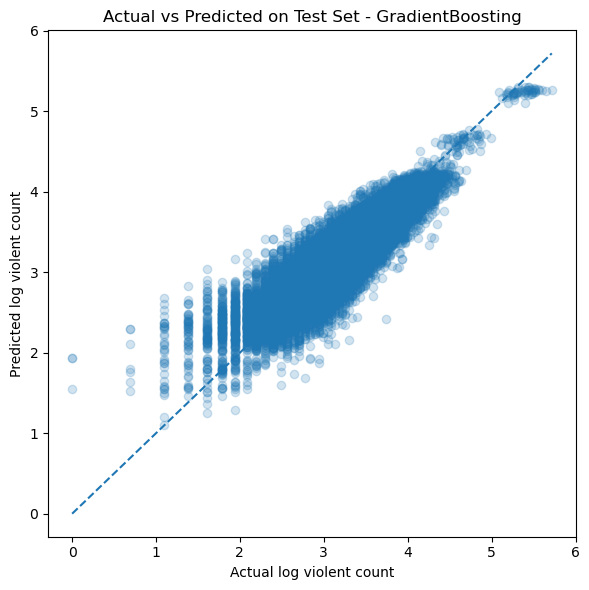

In [37]:
# actual vs predicted on test set
plt.figure(figsize=(6, 6))
plt.scatter(y_test, test_pred, alpha=0.2)
plt.xlabel("Actual log violent count")
plt.ylabel("Predicted log violent count")
plt.title(f"Actual vs Predicted on Test Set - {best_model_name}")

# 45-degree reference line
line_min = min(y_test.min(), test_pred.min())
line_max = max(y_test.max(), test_pred.max())
plt.plot([line_min, line_max], [line_min, line_max], linestyle="--")

plt.tight_layout()
plt.show()

### 5.3 Feature-Set Ablation Study

Feature-set ablation study further examine the contribution of different feature types to predictive performance. It demonstrates the model’s predictions are primarily grounded in the continuity of past crime patterns (validation RMSE=0.2618, test RMSE=0.2713). But the inclusion of calendar and static features resulted in a slight improvement in both validation and test performance.

In [38]:
# define feature set
history_features = ["violent_lag1","violent_lag2","violent_roll3","violent_roll6","violent_roll12","violent_std3",
                    "robbery_lag1","burglary_lag1","theft_lag1","drug_offences_lag1","public_order_offences_lag1","vehicle_offences_lag1"]
calendar_features = ["year","month_num","quarter","is_summer","is_december"]
static_features_model = ["pct_purpose_built_flat","pct_detached","unemployment_rate","inactivity_rate","pct_age_15_24","pct_bad_very_bad"]

feature_sets = {
    "History only": history_features,
    "History + Calendar": history_features + calendar_features,
    "History + Calendar + Static": history_features + calendar_features + static_features_model
}

In [39]:
# run ablation 
def clone_model_by_name(model_name):
    if model_name == "DecisionTree":
        return DecisionTreeRegressor(
            max_depth=8,
            min_samples_leaf=20,
            random_state=42
        )
    elif model_name == "RandomForest":
        return RandomForestRegressor(
            n_estimators=150,
            max_depth=None,
            min_samples_leaf=5,
            n_jobs=-1,
            random_state=42
        )
    elif model_name == "GradientBoosting":
        return GradientBoostingRegressor(
            n_estimators=150,
            learning_rate=0.05,
            max_depth=3,
            subsample=0.8,
            random_state=42
        )
    else:
        raise ValueError("Unknown model name")

ablation_results = []

for set_name, cols in feature_sets.items():
    print(f"Training ablation model: {set_name}")
    
    model = clone_model_by_name(best_model_name)
    model.fit(train_df[cols], y_train)
    
    valid_metrics = evaluate_regression(model, valid_df[cols], y_valid, split_name="validation")
    test_metrics = evaluate_regression(model, test_df[cols], y_test, split_name="test")
    
    valid_metrics.insert(0, "feature_set", set_name)
    test_metrics.insert(0, "feature_set", set_name)
    
    ablation_results.append(valid_metrics)
    ablation_results.append(test_metrics)

ablation_df = pd.concat(ablation_results, ignore_index=True)

ablation_valid = ablation_df[ablation_df["split"] == "validation"].sort_values("RMSE").reset_index(drop=True)
ablation_test = ablation_df[ablation_df["split"] == "test"].sort_values("RMSE").reset_index(drop=True)

display(ablation_valid)
display(ablation_test)

Training ablation model: History only
Training ablation model: History + Calendar
Training ablation model: History + Calendar + Static


,feature_set,split,RMSE,MAE,R2
0,History + Calendar + Static,validation,0.258167,0.200266,0.805401
1,History + Calendar,validation,0.258384,0.200623,0.805074
2,History only,validation,0.261821,0.202644,0.799853


,feature_set,split,RMSE,MAE,R2
0,History + Calendar + Static,test,0.267935,0.204497,0.793925
1,History + Calendar,test,0.268344,0.204785,0.793296
2,History only,test,0.271291,0.206525,0.788732


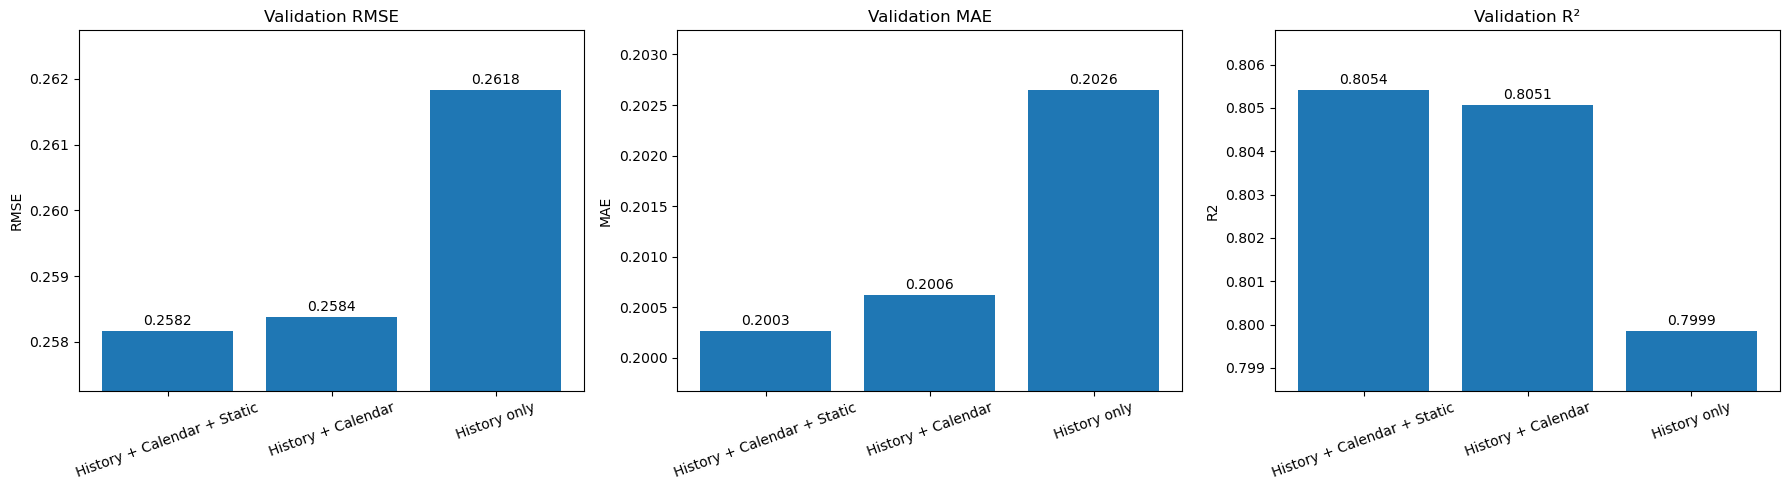

In [40]:
# plot ablation results
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics = [("RMSE", "Validation RMSE"),
           ("MAE", "Validation MAE"),
           ("R2", "Validation R²")]

for ax, (metric, title) in zip(axes, metrics):
    if metric in ["RMSE", "MAE"]:tmp = ablation_valid.sort_values(metric, ascending=True)
    else:tmp = ablation_valid.sort_values(metric, ascending=False)
    
    bars = ax.bar(tmp["feature_set"], tmp[metric])
    ax.set_title(title)
    ax.set_ylabel(metric)
    ax.tick_params(axis="x", rotation=20)
    
    y = tmp[metric].values
    y_min, y_max = y.min(), y.max()
    pad = (y_max - y_min) * 0.25 if y_max > y_min else 0.05
    ax.set_ylim(y_min - pad, y_max + pad)
    
    for bar, v in zip(bars, tmp[metric]):
        ax.text(bar.get_x() + bar.get_width() / 2,
                v + pad * 0.05,f"{v:.4f}",ha="center",va="bottom")
        
plt.tight_layout()
plt.show()

### 5.4 Feature Importance + PDP & SHAP Interpretation

#### 5.4.1 Permutation Importance

Permutation Importance is used to identify which variables are critical to predictive performance. The results indicate the model relies primarily on the rolling averages of violent crime history over the past 12 and 3 months. Furthermore, monthly information emerged as the highest-ranked non-crime-history variable. Other crime lags provide supplementary information that is minor yet discernible.

In [41]:
# permutation importance on validation set
perm = permutation_importance(best_model,
                              X_valid, y_valid,
                              n_repeats=10, random_state=42,
                              scoring="neg_mean_absolute_error")

importance_df = pd.DataFrame({"feature": X_valid.columns,
                              "importance_mean": perm.importances_mean,
                              "importance_std": perm.importances_std
                             }).sort_values("importance_mean", ascending=False)
importance_df.head(10)

,feature,importance_mean,importance_std
4,violent_roll12,0.281769,0.002043
2,violent_roll3,0.018569,0.000567
0,violent_lag1,0.006452,0.000242
19,month_num,0.005742,0.000523
10,public_order_offences_lag1,0.002038,0.000151
8,theft_lag1,0.000855,0.000100
3,violent_roll6,0.000196,0.000102
21,is_summer,0.000186,0.000040
1,violent_lag2,0.000158,0.000014
9,drug_offences_lag1,0.000155,0.000058


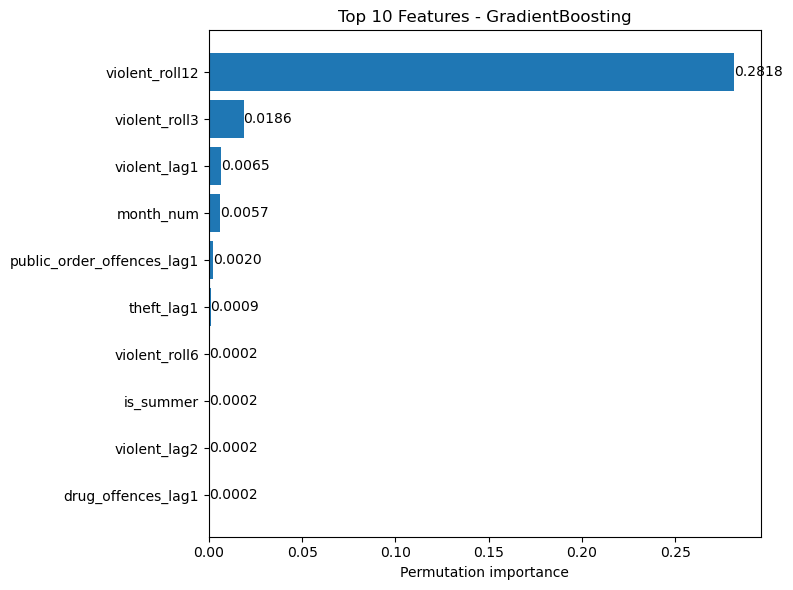

In [42]:
# top 10 feature importances
top_n = 10
plot_df = importance_df.head(10).sort_values("importance_mean", ascending=True)

plt.figure(figsize=(8, 6))
bars = plt.barh(plot_df["feature"], plot_df["importance_mean"])
plt.xlabel("Permutation importance")
plt.title(f"Top {top_n} Features - {best_model_name}")
for bar, v in zip(bars, plot_df["importance_mean"]):
    plt.text(bar.get_width(), bar.get_y() + bar.get_height() / 2, f"{v:.4f}", va="center")

plt.tight_layout()
plt.show()

#### 5.4.2 Grouped Permutation Importance

The results of the Grouped Permutation Importance are consistent with the findings of the Feature-Set Ablation Study.

In [43]:
# assign feature grpup
def assign_feature_group(feature):
    if feature in ["violent_lag1", "violent_lag2", "violent_roll3", "violent_roll6", "violent_roll12", "violent_std3"]:
        return "Violent crime history"
    elif feature.endswith("_lag1"):
        return "Other crime lags"
    elif feature in static_features_model:
        return "Static ward features"
    elif feature in calendar_features:
        return "Calendar features"
    else:
        return "Other"

In [44]:
# grouped permutation importance
importance_grouped = importance_df.copy()
importance_grouped["feature_group"] = importance_grouped["feature"].apply(assign_feature_group)

group_importance = (importance_grouped.groupby("feature_group", as_index=False)["importance_mean"]
                    .sum().sort_values("importance_mean", ascending=False))
display(group_importance)

,feature_group,importance_mean
3,Violent crime history,0.307156
0,Calendar features,0.005926
1,Other crime lags,0.003203
2,Static ward features,0.000223


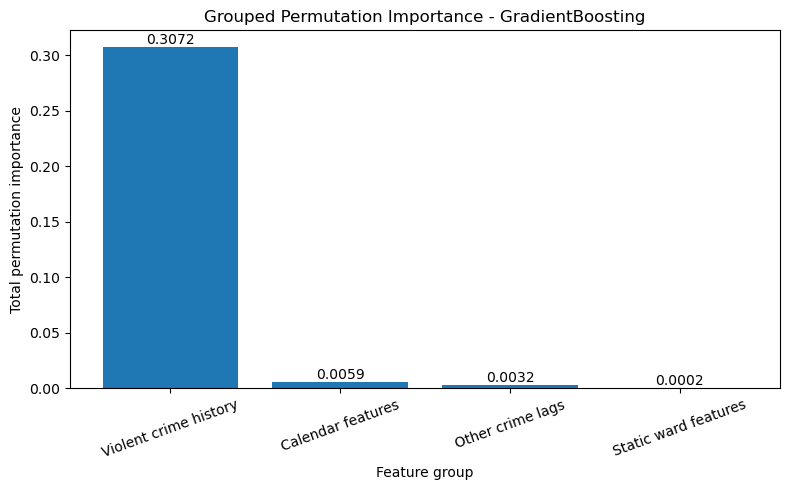

In [45]:
# plot grouped permutation importance
plt.figure(figsize=(8, 5))
bars = plt.bar(group_importance["feature_group"], group_importance["importance_mean"])
plt.title(f"Grouped Permutation Importance - {best_model_name}")
plt.xlabel("Feature group")
plt.ylabel("Total permutation importance")
plt.xticks(rotation=20)

for bar, v in zip(bars, group_importance["importance_mean"]):
    plt.text(bar.get_x() + bar.get_width() / 2,
        v,f"{v:.4f}",ha="center",va="bottom")

plt.tight_layout()
plt.show()

#### 5.4.3 Partial Dependence Plots (PDP)

The PDPs illustrate the average trend of the model’s predicted values as three most important variables change. violent_roll12 exhibits a distinct positive relationship, while violent_roll3 and violent_lag1 display weak positive relationships. This indicates that long-term historical levels are more significant than single-month lagged values, suggesting ward-level violent crime possesses strong spatial stability.

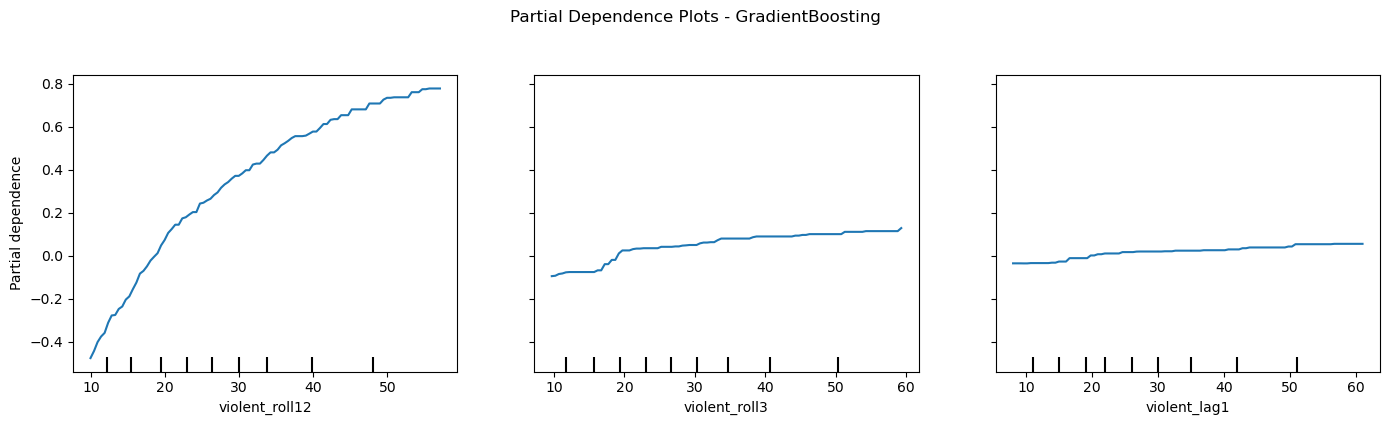

In [46]:
# select top 3 features for partial dependence plots
top_features = importance_df.head(3)["feature"].tolist()
fig, ax = plt.subplots(figsize=(14, 4))
PartialDependenceDisplay.from_estimator(best_model,
                                        X_valid,
                                        features=top_features,
                                        kind="average", ax=ax)
plt.suptitle(f"Partial Dependence Plots - {best_model_name}", y=1.05)
plt.tight_layout()
plt.show()

#### 5.4.4 SHapley Additive exPlanations (SHAP)

SHAP demonstrates how feature values drive individual predictions to fluctuate upward or downward. Its ranking aligns closely with that of permutation importance, yet it additionally reveals the directional impact of variable values.

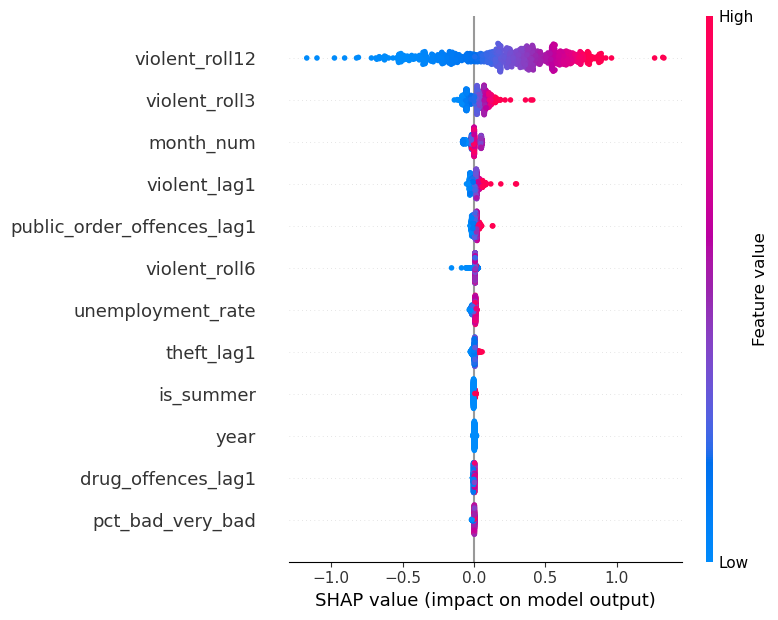

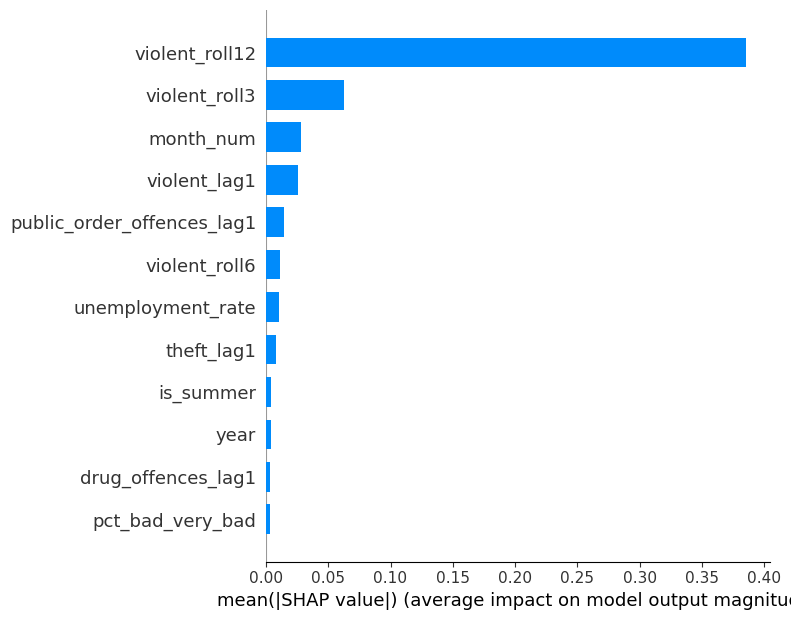

In [47]:
# Use a sample of validation data for speed and readability
X_shap = X_valid.sample(min(1000, len(X_valid)), random_state=42)

# SHAP for the best tree-based model
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_shap)

# SHAP beeswarm summary
shap.summary_plot(shap_values, X_shap, max_display=12, show=True)
# SHAP bar summary
shap.summary_plot(shap_values, X_shap, plot_type="bar", max_display=12, show=True)

### 5.5 Residual Analysis

The residual distribution indicates that the majority of residuals are concentrated around zero, exhibiting an approximately bell-shaped distribution. Gradient Boosting model does not display any significant systematic bias. However, it reveals the presence of certain tails, suggesting that the model still contains some ward-month observations that are significantly overestimated or underestimated. Besides, above-expectation and below-expectation do not perfectly correspond to absolute high-crime and low-crime at both ward-level and borough-level. There may be local risk factors, protective factors, or trend factors that the current model has not fully captured. In the temporal dimension, the mean residual repeatedly exceeds zero, reflecting the presence of new temporal variations during the test period that were not fully captured by the training data and existing features.

In [48]:
# build residual dataframe on test set
residual_df = test_df[["WardCode", "WardName", "Borough", "month", "violent_count", "target_log_count"]].copy()

residual_df["pred_log_count"] = test_pred
residual_df["pred_count"] = np.expm1(residual_df["pred_log_count"])
residual_df["residual_log"] = residual_df["target_log_count"] - residual_df["pred_log_count"]
residual_df["residual_count"] = residual_df["violent_count"] - residual_df["pred_count"]

residual_df.head()

,WardCode,WardName,Borough,month,violent_count,target_log_count,pred_log_count,pred_count,residual_log,residual_count
165,E05009317,Bethnal Green,Tower Hamlets,2024-01-01,58,4.077537,4.147194,62.256250,-0.069656,-4.256250
166,E05009317,Bethnal Green,Tower Hamlets,2024-02-01,65,4.189655,4.075700,57.891676,0.113955,7.108324
167,E05009317,Bethnal Green,Tower Hamlets,2024-03-01,57,4.060443,4.156883,62.872104,-0.096440,-5.872104
168,E05009317,Bethnal Green,Tower Hamlets,2024-04-01,57,4.060443,4.103851,59.573117,-0.043408,-2.573117
169,E05009317,Bethnal Green,Tower Hamlets,2024-05-01,59,4.094345,4.167203,63.534686,-0.072858,-4.534686


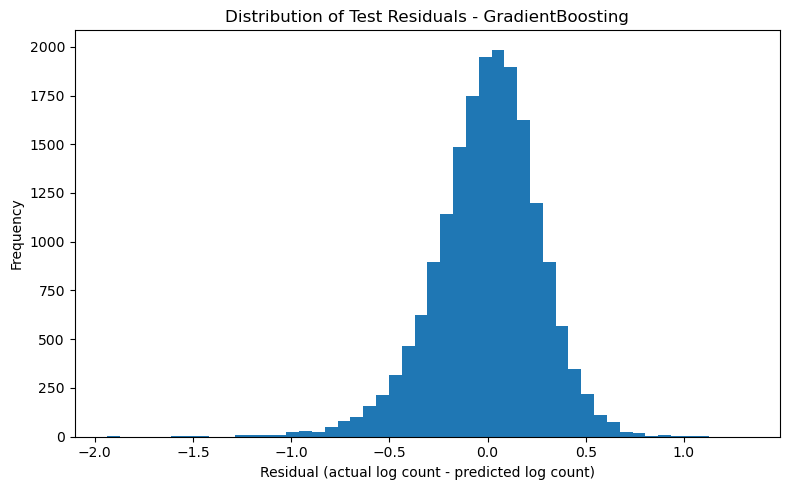

In [49]:
# residual distribution
plt.figure(figsize=(8, 5))
plt.hist(residual_df["residual_log"], bins=50)
plt.xlabel("Residual (actual log count - predicted log count)")
plt.ylabel("Frequency")
plt.title(f"Distribution of Test Residuals - {best_model_name}")
plt.tight_layout()
plt.show()

In [50]:
# aggregate residuals by ward
ward_residuals = (residual_df.groupby(["WardCode", "WardName", "Borough"], as_index=False)
                  .agg(mean_actual_log=("target_log_count", "mean"),
                       mean_pred_log=("pred_log_count", "mean"),
                       mean_actual_count=("violent_count", "mean"),
                       mean_pred_count=("pred_count", "mean"),
                       mean_residual_log=("residual_log", "mean"),
                       mean_residual_count=("residual_count", "mean"),
                       months_in_test=("month", "count")
                      )
                  .sort_values("mean_residual_log", ascending=False))
ward_residuals.head()

,WardCode,WardName,Borough,mean_actual_log,mean_pred_log,mean_actual_count,mean_pred_count,mean_residual_log,mean_residual_count,months_in_test
459,E05013806,St James's,Westminster,5.450916,5.246284,233.703704,189.020858,0.204632,44.682846,27
116,E05011251,Seven Kings,Redbridge,4.433246,4.296753,84.481481,73.433931,0.136493,11.047550,27
608,E05014027,Wandsworth Common,Wandsworth,4.044229,3.937008,57.592593,50.403584,0.107221,7.189008,27
411,E05013758,Cheam,Sutton,2.445505,2.346942,11.000000,9.479970,0.098562,1.520030,27
480,E05013827,West Barnes,Merton,2.643533,2.547929,13.629630,11.898481,0.095604,1.731149,27


In [51]:
# top 15 wards above model expectation
above_expected = ward_residuals.sort_values("mean_residual_log", ascending=False).head(15)
above_expected[["WardCode", "WardName", "Borough", "mean_actual_count", "mean_pred_count", "mean_residual_count", "mean_residual_log"]]

,WardCode,WardName,Borough,mean_actual_count,mean_pred_count,mean_residual_count,mean_residual_log
459,E05013806,St James's,Westminster,233.703704,189.020858,44.682846,0.204632
116,E05011251,Seven Kings,Redbridge,84.481481,73.433931,11.047550,0.136493
608,E05014027,Wandsworth Common,Wandsworth,57.592593,50.403584,7.189008,0.107221
411,E05013758,Cheam,Sutton,11.000000,9.479970,1.520030,0.098562
480,E05013827,West Barnes,Merton,13.629630,11.898481,1.731149,0.095604
383,E05013730,Rushey Green,Lewisham,71.962963,64.812680,7.150283,0.094777
537,E05013936,King George's & Sunray,Kingston upon Thames,8.740741,7.113466,1.627275,0.093033
643,E05014084,Kidbrooke Village & Sutcliffe,Greenwich,15.111111,12.900720,2.210391,0.091052
592,E05014011,East Putney,Wandsworth,23.555556,21.200535,2.355021,0.083863
461,E05013808,West End,Westminster,199.370370,183.790454,15.579916,0.076305


In [52]:
# top 15 wards below model expectation
below_expected = ward_residuals.sort_values("mean_residual_log", ascending=True).head(15)
below_expected[["WardCode", "WardName", "Borough", "mean_actual_count", "mean_pred_count", "mean_residual_count", "mean_residual_log"]]

,WardCode,WardName,Borough,mean_actual_count,mean_pred_count,mean_residual_count,mean_residual_log
479,E05013826,Wandle,Merton,11.703704,13.389786,-1.686083,-0.180821
428,E05013775,East Sheen,Richmond upon Thames,7.777778,8.551027,-0.773249,-0.135345
51,E05009398,Norland,Kensington and Chelsea,8.962963,9.528731,-0.565768,-0.122831
443,E05013790,West Twickenham,Richmond upon Thames,10.148148,10.952376,-0.804228,-0.109408
37,E05009384,Stamford Hill West,Hackney,10.814815,11.809124,-0.994309,-0.109143
334,E05013681,Grange Park,Enfield,4.962963,5.188465,-0.225502,-0.106877
386,E05013733,Addison,Hammersmith and Fulham,21.518519,23.313560,-1.795042,-0.104727
464,E05013811,Cannon Hill,Merton,9.000000,9.371705,-0.371705,-0.092575
395,E05013742,Lillie,Hammersmith and Fulham,16.851852,17.617810,-0.765959,-0.090696
501,E05013900,Upper Walthamstow,Waltham Forest,13.259259,13.840095,-0.580836,-0.090013


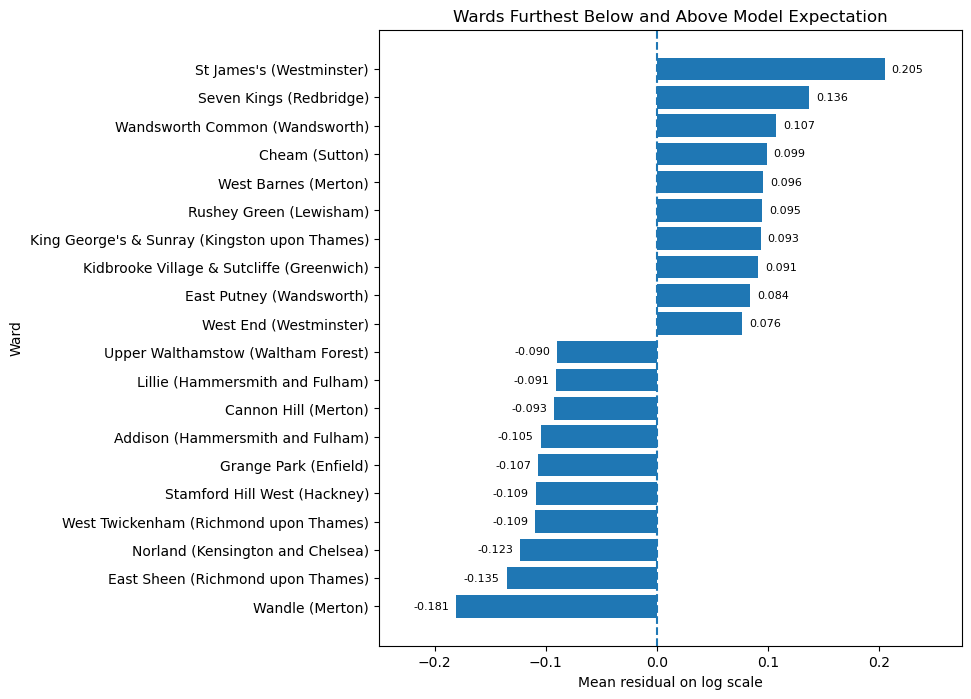

In [53]:
# Plot top above and below expected wards bar chart
top_above = ward_residuals.sort_values("mean_residual_log", ascending=False).head(10).copy()
top_below = ward_residuals.sort_values("mean_residual_log", ascending=True).head(10).copy()
top_above["direction"] = "Above expectation"
top_below["direction"] = "Below expectation"
residual_top_bottom = pd.concat([top_below, top_above], ignore_index=True)
residual_top_bottom = residual_top_bottom.sort_values("mean_residual_log", ascending=True)
labels = residual_top_bottom["WardName"] + " (" + residual_top_bottom["Borough"] + ")"
values = residual_top_bottom["mean_residual_log"]

fig, ax = plt.subplots(figsize=(11, 8))
bars = ax.barh(labels, values)
ax.axvline(0, linestyle="--")
ax.set_xlabel("Mean residual on log scale")
ax.set_ylabel("Ward")
ax.set_title("Wards Furthest Below and Above Model Expectation")

x_min = min(values.min(), 0)
x_max = max(values.max(), 0)
x_range = x_max - x_min
x_pad = x_range * 0.18
ax.set_xlim(x_min - x_pad, x_max + x_pad)

for bar, v in zip(bars, values):
    y = bar.get_y() + bar.get_height() / 2
    if v >= 0:
        ax.annotate(f"{v:.3f}",xy=(v, y),xytext=(5, 0),
                    textcoords="offset points",ha="left",va="center",fontsize=8)
    else:
        ax.annotate(f"{v:.3f}",xy=(v, y),xytext=(-5, 0),
                    textcoords="offset points",ha="right",va="center",fontsize=8)

plt.subplots_adjust(left=0.42, right=0.95)
plt.show()

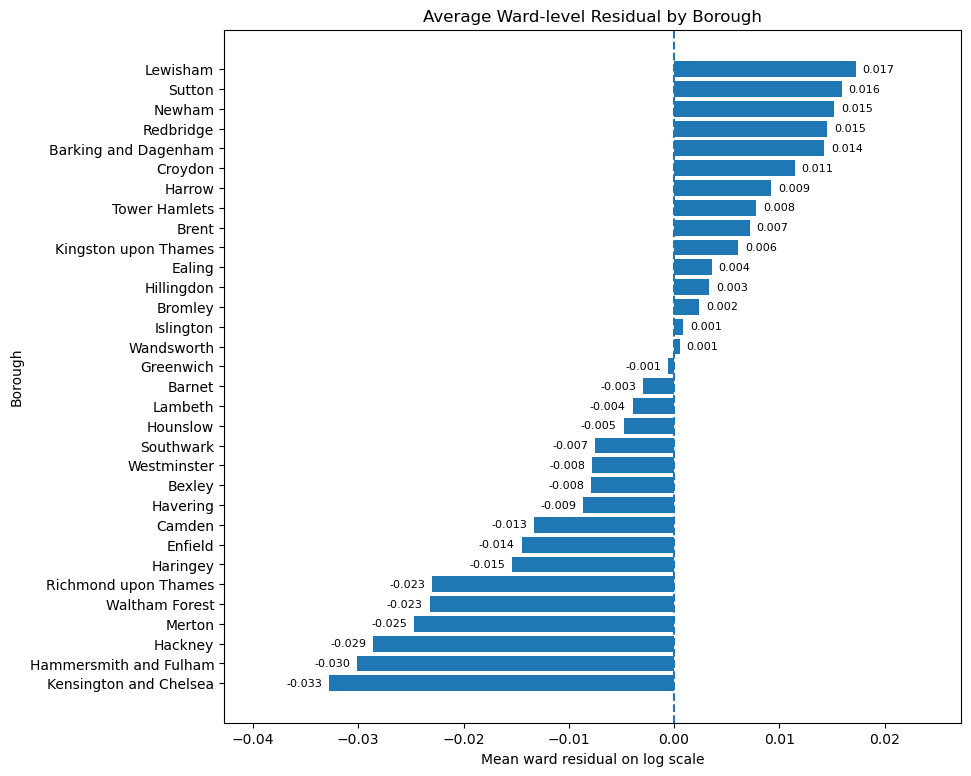

,Borough,mean_residual_log,mean_residual_count,n_wards
18,Kensington and Chelsea,-0.032754,0.133993,18
11,Hammersmith and Fulham,-0.030132,0.183649,21
10,Hackney,-0.028589,-0.078706,21
22,Merton,-0.024697,0.274191,20
29,Waltham Forest,-0.023215,0.205670,22


In [54]:
# Borough-level mean residual ranking
borough_residuals = (ward_residuals.groupby("Borough", as_index=False)
                     .agg(mean_residual_log=("mean_residual_log", "mean"),
                          mean_residual_count=("mean_residual_count", "mean"),
                          n_wards=("WardCode", "count"))
                     .sort_values("mean_residual_log", ascending=True))

labels = borough_residuals["Borough"]
values = borough_residuals["mean_residual_log"]
fig, ax = plt.subplots(figsize=(11, 9))
bars = ax.barh(labels, values)
ax.axvline(0, linestyle="--")
ax.set_xlabel("Mean ward residual on log scale")
ax.set_ylabel("Borough")
ax.set_title("Average Ward-level Residual by Borough")

x_min = min(values.min(), 0)
x_max = max(values.max(), 0)
x_range = x_max - x_min
x_pad = x_range * 0.20
ax.set_xlim(x_min - x_pad, x_max + x_pad)

for bar, v in zip(bars, values):
    y = bar.get_y() + bar.get_height() / 2
    if v >= 0:
        ax.annotate(f"{v:.3f}",xy=(v, y),xytext=(5, 0),
                    textcoords="offset points",ha="left",va="center",fontsize=8)
    else:
        ax.annotate(f"{v:.3f}",xy=(v, y),xytext=(-5, 0),
                    textcoords="offset points",ha="right",va="center",fontsize=8)
        
plt.subplots_adjust(left=0.28, right=0.95)
plt.show()
borough_residuals.head()

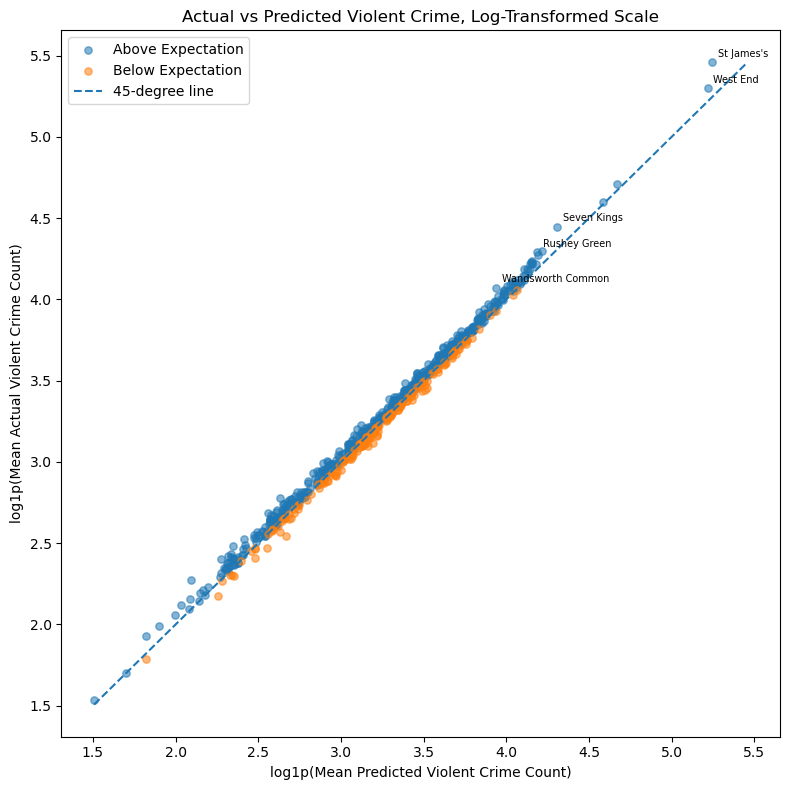

In [55]:
# Actual vs predicted: log1p-transformed scale
above = ward_residuals[ward_residuals["mean_residual_count"] > 0].copy()
below = ward_residuals[ward_residuals["mean_residual_count"] <= 0].copy()
fig, ax = plt.subplots(figsize=(8, 8))

# log1p transform for visualisation
above["log_pred_count"] = np.log1p(above["mean_pred_count"])
above["log_actual_count"] = np.log1p(above["mean_actual_count"])
below["log_pred_count"] = np.log1p(below["mean_pred_count"])
below["log_actual_count"] = np.log1p(below["mean_actual_count"])

ax.scatter(above["log_pred_count"],above["log_actual_count"],alpha=0.55,s=28,label="Above Expectation")
ax.scatter(below["log_pred_count"],below["log_actual_count"],alpha=0.55,s=28,label="Below Expectation")

# label top 5 wards with largest absolute residual
label_df = ward_residuals.reindex(ward_residuals["mean_residual_count"].abs().sort_values(ascending=False).index).head(5).copy()

label_df["log_pred_count"] = np.log1p(label_df["mean_pred_count"])
label_df["log_actual_count"] = np.log1p(label_df["mean_actual_count"])

for _, row in label_df.iterrows():
    ax.annotate(row["WardName"],xy=(row["log_pred_count"], row["log_actual_count"]),xytext=(4, 4),textcoords="offset points",fontsize=7)

# 45-degree line on log1p scale
line_min = min(above["log_pred_count"].min(),
               below["log_pred_count"].min(),
               above["log_actual_count"].min(),
               below["log_actual_count"].min())
line_max = max(above["log_pred_count"].max(),
               below["log_pred_count"].max(),
               above["log_actual_count"].max(),
               below["log_actual_count"].max())
ax.plot([line_min, line_max],
        [line_min, line_max],
        linestyle="--",label="45-degree line")

ax.set_xlabel("log1p(Mean Predicted Violent Crime Count)")
ax.set_ylabel("log1p(Mean Actual Violent Crime Count)")
ax.set_title("Actual vs Predicted Violent Crime, Log-Transformed Scale")
ax.legend()
plt.tight_layout()
plt.show()

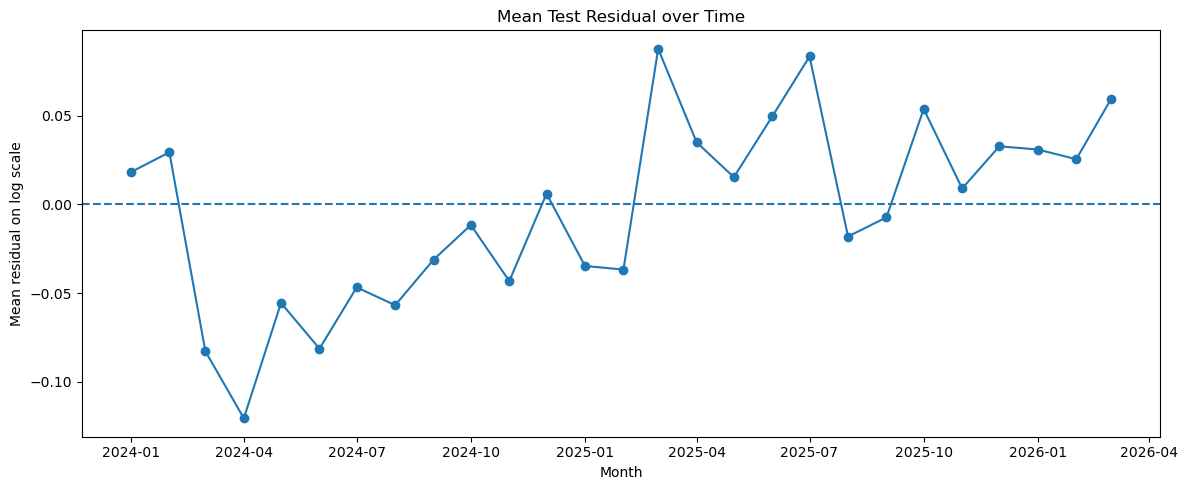

In [56]:
# monthly mean residual over test period
monthly_residuals = (residual_df.groupby("month", as_index=False)
                     .agg(mean_residual_log=("residual_log", "mean"),
                          mean_residual_count=("residual_count", "mean"))
                     .sort_values("month"))
plt.figure(figsize=(12, 5))
plt.plot(monthly_residuals["month"], monthly_residuals["mean_residual_log"], marker="o")
plt.axhline(0, linestyle="--")
plt.title("Mean Test Residual over Time")
plt.xlabel("Month")
plt.ylabel("Mean residual on log scale")
plt.tight_layout()
plt.show()

## 6. Conclusion

[[ go back to the top ]](#Table-of-contents)

Overall, Gradient Boosting performs well in predicting violent crime at the ward level in London, relying primarily on historical crime characteristics. However, certain wards continue to deviate from the model’s expectations, even after accounting for seasonality and static features, and should therefore be prioritized as key subjects for future analysis regarding urban safety and local mechanisms.

## 7. References

[[ go back to the top ]](#Table-of-contents)

Bogomolov, A., Lepri, B., Staiano, J., Oliver, N., Pianesi, F. and Pentland, A., 2014, November. Once upon a crime: towards crime prediction from demographics and mobile data. In Proceedings of the 16th international conference on multimodal interaction (pp. 427-434).

Bowers, K.J., Johnson, S.D. and Pease, K., 2004. Prospective hot-spotting: the future of crime mapping?. British journal of criminology, 44(5), pp.641-658.

Sampson, R.J., Raudenbush, S.W. and Earls, F., 1997. Neighborhoods and violent crime: A multilevel study of collective efficacy. science, 277(5328), pp.918-924.

Weisburd, D., 2015. The law of crime concentration and the criminology of place. Criminology, 53(2), pp.133-157.